# Table of contents

* **Introduction**
* **Objective**
* **Multi-Layer Perceptron (MLP) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture and Model Training (Keras)
    * Model Architecture and Model Training (TensorFlow custom functions)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This tutorial focuses on implementing a Multi-Layer Perceptron ($\text{MLP}$), a foundational deep learning model, within the TensorFlow/Keras framework for binary classification. The application domain is malware detection, where the model learns to differentiate malicious (1) from benign (0) programs. The input data consists of dynamic API call sequences represented as $100$ sequential features ($\mathbf{t_0}$ to $\mathbf{t_99}$). The core objective is to develop a deep feedforward network that can leverage these behavioral patterns to establish a non-linear decision boundary capable of effective threat identification.

# Objective

The central objective is to develop a highly effective $\text{MLP}$ classifier for detecting malware based on high-dimensional API call sequences. This process addresses three significant, concurrent challenges typical of real-world security datasets:

- Class Imbalance: Managing the highly skewed distribution between malware and goodware samples.
- High Dimensionality: Efficiently processing the $100$ input features.
- Non-linear Decision Boundaries: Leveraging the deep architecture of the $\text{MLP}$ to capture complex relationships within the data.

Beyond classification performance, the project aims to demonstrate robust deep learning workflow best practices, including strategic preprocessing, effective regularization, and a comprehensive evaluation tailored to imbalanced datasets. It also includes an educational comparison between standard Keras layers and custom layer implementation for advanced flexibility.

# Multi-Layer Perceptron (MLP) Foundations

The Multi-Layer Perceptron ($\text{MLP}$), often referred to as a standard feedforward neural network, is a fundamental architecture in deep learning. Its core concept is the ability to learn complex, non-linear mappings between input data and output targets.

**The Universal Approximation Theorem**

The theoretical power of the $\text{MLP}$ is rooted in the Universal Approximation Theorem. This theorem states that a feedforward network with a single hidden layer and a non-linear activation function is theoretically capable of approximating any continuous function to an arbitrary level of accuracy, provided it has a sufficient number of neurons. This capability allows the $\text{MLP}$ to solve non-linearly separable problems, unlike simpler models such as the Perceptron.

**Learning Mechanism**

The $\text{MLP}$ learns through a two-step process:

- Forward Propagation: Input data moves through the network, from the input layer to the output layer, where a prediction is generated.
- Backpropagation: The error (the difference between the prediction and the true target) is calculated. This error is then propagated backward through the network, layer by layer. This process uses the chain rule of calculus to determine the gradient of the loss function with respect to every single weight in the network. These gradients indicate the direction and magnitude by which the weights must be adjusted.
- Optimization: An optimization algorithm (like $\text{SGD}$ or $\text{Adam}$) uses these gradients to update the weights, iteratively minimizing the overall error.

**MLP Composition and Structure**

The $\text{MLP}$ is organized into a minimum of three distinct types of layers:

**1. The Input Layer**

This layer receives the raw data features. It does not perform any computation; its nodes simply represent the input variables, passing the feature values directly to the next layer. The number of neurons in the input layer is always equal to the number of features in the dataset ($\mathbf{N_{features}}$).

**2. Hidden Layers**

These are the computational engine of the network, positioned between the input and output layers. A network is considered "deep" when it contains multiple hidden layers.

- Synaptic Connections (Weights): Each neuron in a hidden layer is connected to every neuron in the preceding layer. Each connection has an associated weight ($\mathbf{W}$), which is a trainable parameter that determines the strength of the connection.
- Bias: Each neuron also has a bias ($\mathbf{b}$), another trainable parameter that allows the activation function to be shifted, providing flexibility in the model's ability to fit the data.
- Activation Function: After the linear combination of weighted inputs and bias ($\mathbf{Z} = \mathbf{W} \cdot \mathbf{X} + \mathbf{b}$), the result is passed through a non-linear activation function (e.g., $\text{ReLU}$, $\text{Sigmoid}$, or $\text{Tanh}$). This non-linearity is essential for the $\text{MLP}$ to learn complex relationships and avoid simply collapsing into a linear model.

**3. The Output Layer**

This final layer produces the network's prediction. The number of neurons and the choice of activation function depend directly on the type of task:
- Binary Classification (e.g., malware vs. benign): Typically uses one neuron with a $\text{Sigmoid}$ activation, which outputs a probability between 0 and 1.
- Multi-class Classification (e.g., classifying images into 10 categories): Uses $N$ neurons (where $N$ is the number of classes) with a $\text{Softmax}$ activation, which converts the raw outputs into a probability distribution summing to 1.
- Regression (e.g., predicting house prices): Typically uses one neuron with no activation function (or a linear activation).

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">hash</td>
    <td class="tg-7zrl">Unique identifier for each record</td>
    <td class="tg-7zrl">Alphanumeric</td>
  </tr>
  <tr>
    <td class="tg-7zrl">t_0 - t_99</td>
    <td class="tg-7zrl">Time series measurement at index 0-99</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">malware</td>
    <td class="tg-7zrl">Goodware (0) and Malware (1)</td>
    <td class="tg-7zrl">Categorical (Class)</td>
  </tr>
</tbody>
</table>

**[Dataset Link](https://www.kaggle.com/datasets/ang3loliveira/malware-analysis-datasets-api-call-sequences)**

# Pipeline Overview

The machine learning pipeline is executed in a six-stage sequence designed for robustness and reproducibility:
- Data Loading and Exploration: Initial data inspection and preparation.
- Preprocessing Pipeline: Data cleaning, splitting, and standardization.
- Feature Engineering & Scaling: $\text{StandardScaler}$ application, $\text{PCA}$ for dimensionality reduction, and $\text{SMOTE}$ for class balancing (on the training set only).
- Model Development: Construction and compilation of the two $\text{MLP}$ architectures.
- Training: Fitting the models using the balanced data, monitored by $\text{EarlyStopping}$.
- Evaluation & Visualization: Comprehensive metric calculation on the held-out test set and visual analysis of model performance.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing strategy prioritizes data quality and suitability for a neural network, which is sensitive to feature scale and distribution.

**Feature Transformation and Scaling**

The pipeline begins by removing the non-predictive hash identifier column and managing missing values by excluding affected records. The data is then subjected to a stratified train-test split to ensure the original class ratio is preserved in both the training (80%) and testing (20%) sets. All numerical features are processed using StandardScaler to achieve zero mean and unit variance. This standardization is critical, as it prevents features with larger magnitudes from dominating the gradient descent process during network training.

**Dimensionality Reduction and Imbalance Correction**

Principal Component Analysis ($\text{PCA}$) is applied to transform the $100$ features into a reduced dimensional space. This step mitigates the curse of dimensionality, reduces computational cost, and aids in the visual interpretation of the data distribution. Following $\text{PCA}$, the training data's severe class imbalance is addressed using the Synthetic Minority Over-sampling Technique ($\text{SMOTE}$). $\text{SMOTE}$ generates synthetic examples for the minority class, effectively balancing the training set distribution and allowing the $\text{MLP}$ to learn the characteristics of the underrepresented class more effectively.

**Model Training Approach**

The training phase utilized two parallel $\text{MLP}$ implementations to showcase TensorFlow's flexibility.

**Architecture and Optimization**

Both models employed a standard feedforward architecture: two hidden $\mathbf{Dense}$ layers, each with $64$ neurons and the $\mathbf{ReLU}$ activation function, followed by a final output $\mathbf{Dense}$ layer with $1$ neuron and the $\mathbf{Sigmoid}$ activation, appropriate for binary classification. The models were compiled using the $\mathbf{Adam}$ optimizer, set with a low learning rate ($0.0001$) to promote stable convergence, and optimized against the Binary Cross-Entropy loss function.

**Regularization and Customization**

EarlyStopping was implemented as a crucial regularization technique. This callback monitored the validation loss (`val_loss`) and, after a specified patience threshold (10 epochs), halted training and restored the weights from the epoch with the best performance. This practice is essential for preventing overfitting to the complex $\text{SMOTE}$-enhanced training set. The project featured two implementations:

- Standard Keras $\text{MLP}$: Built efficiently using the $\text{Sequential}$ API.
- Custom Layer $\text{MLP}$: A custom $\text{CustomDenseLayer}$ was implemented by subclassing `tf.keras.layers.Layer`, demonstrating manual control over layer parameters (weights and biases) and the forward pass computation.

**Model Evaluation Approach**

Evaluation was rigorous and tailored to the characteristics of an imbalanced classification problem, ensuring the model's performance on the original, unseen test data is accurately assessed.

**Metrics and Error Analysis**

The model was evaluated using its predictions on the original, unbalanced test set. Beyond simple $\text{Accuracy}$, critical metrics were calculated:

- Confusion Matrix ($\text{CM}$): Used to analyze the specific error types ($\text{False Positives}$ and $\text{False Negatives}$) of the malware classifier.
- Macro-Averaged Metrics: Precision, Recall, and F1-score were macro-averaged to provide an unbiased measure of performance across both the minority and majority classes, which is paramount in security applications where missing a single malware sample ($\text{False Negative}$) is highly costly.
- AUC-ROC Score: Calculated to assess the model's probability-based discriminative ability, independent of the chosen classification threshold.

**Visualization of Generalization**

Visualization techniques provided intuitive insight into the model's behavior:

- Training Curves: Plots of loss and accuracy for both training and validation sets were monitored to confirm the learning process and the efficacy of $\text{EarlyStopping}$.
- Decision Boundary: The model's learned separation regions were plotted onto the 2D $\text{PCA}$ space for both the training and test data. This visualization directly demonstrates how well the model generalizes its complex boundary to the unseen test set.
- Precision-Recall and ROC Curves: These curves were generated for each class to illustrate the trade-off between sensitivity and specificity, further clarifying the model's performance profile under the pressure of class imbalance.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
!pip install imbalanced-learn==0.10.1

**Import libraries**

In [ ]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os

from sklearn.utils import shuffle
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve
)
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification 

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

# Data Loading

The process begins with loading the dataset, which contains $100$ sequential features (`t_0` to `t_99`) derived from API calls, along with a $\mathbf{hash}$ identifier and the binary $\mathbf{malware}$ target label. The hash identifier is immediately removed, as it represents a unique, non-predictive identifier of the file and offers no value to a general classification model. The operation of dropping rows containing missing values (`df.dropna(how='any')`) ensures that the subsequent feature engineering and model training steps operate only on complete, valid data samples, maintaining data integrity.

In [ ]:
df = pd.read_csv('/kaggle/input/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv')
df.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


**Initial Cleaning**

In [4]:
df = df.drop(columns=['hash'],axis=1)
df = df.dropna(how='any')
df

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1,82,208,187,208,172,117,172,117,172,117,...,81,240,117,71,297,135,171,215,35,1
2,16,110,240,117,240,117,240,117,240,117,...,65,112,123,65,112,123,65,113,112,1
3,82,208,187,208,172,117,172,117,172,117,...,208,302,208,302,187,208,302,228,302,1
4,82,240,117,240,117,240,117,240,117,172,...,209,260,40,209,260,141,260,141,260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43871,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1
43872,82,240,117,240,117,240,117,240,117,172,...,159,224,82,159,224,82,159,224,82,1
43873,82,240,117,240,117,240,117,240,117,172,...,260,141,260,141,260,141,260,141,260,1
43874,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1


**Splitting Train and Test Dataset**

The clean dataset is partitioned into training ($80%$) and testing ($20%$) sets using the `train_test_split` function. This separation is crucial for robust model validation. The training set is used exclusively for model learning, while the test set is reserved as an unseen, unbiased measure of the model's generalization ability. This split is often performed with stratification (implicitly done by setting a `random_state` and aiming for representative splits, though stratified splitting is the rigorous method), ensuring that the proportion of the target class (`malware`) is maintained across both subsets.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (35100, 101)
test shape: (8776, 101)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

In [6]:
train.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
35602,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
13858,112,274,158,215,274,158,215,298,76,208,...,172,117,172,117,172,117,172,117,172,1
39770,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1024,208,286,76,110,240,117,208,187,208,198,...,286,240,286,117,208,286,240,286,117,1
31154,82,208,187,208,172,117,172,208,16,208,...,117,172,117,208,172,117,100,215,35,1


In [7]:
train.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
count,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,...,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000
mean,142.787123,211.254872,148.203333,188.834245,187.417949,174.108063,170.378148,199.045271,142.807322,167.325413,...,154.204786,173.156809,159.560484,164.906980,173.463419,152.373533,158.394758,160.395926,155.748262,0.975698
std,75.600839,60.294950,47.698712,68.358486,71.255625,65.739453,55.525942,65.516243,66.800136,53.441632,...,78.291792,82.742852,74.071577,70.322547,70.531624,79.906061,78.029384,75.022546,78.949398,0.153987
min,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82.000000,172.000000,117.000000,117.000000,117.000000,117.000000,117.000000,159.000000,117.000000,117.000000,...,81.000000,117.000000,114.000000,117.000000,117.000000,89.000000,100.000000,108.000000,73.000000,1.000000
50%,82.000000,240.000000,158.000000,215.000000,172.000000,158.000000,172.000000,215.000000,117.000000,172.000000,...,141.000000,172.000000,141.000000,171.000000,172.000000,141.000000,171.000000,156.000000,141.000000,1.000000
75%,215.000000,240.000000,172.000000,240.000000,274.000000,240.000000,215.000000,240.000000,208.000000,208.000000,...,240.000000,260.000000,240.000000,215.000000,240.000000,215.000000,224.000000,225.000000,225.000000,1.000000
max,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,...,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,1.000000


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35100 entries, 35602 to 15795
Columns: 101 entries, t_0 to malware
dtypes: int64(101)
memory usage: 27.3 MB


In [9]:
train.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

In [10]:
test.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

**Descriptive Statistics**

Analysis of the descriptive statistics (mean, standard deviation, min/max values) reveals that the API call features (`t_0` to `t_99`) are all numeric and share the same maximum range ($\mathbf{306}$), suggesting they may represent encoded API function IDs. The variation in the means and standard deviations across the features indicates that different API calls appear with varying frequencies or in distinct positions within the $100$-step sequence, necessitating proper scaling for the neural network.

**Target Labels Distribution**

**Impact of Class Imbalance**

This imbalance is a critical challenge in machine learning, particularly in security domains. If a model is trained directly on this data, it risks becoming trivially biased toward the majority class, classifying nearly everything as malware simply by chance. While this might result in high overall accuracy, it would likely yield poor performance (low Recall and F1-score) for the minority class (goodware), making the model practically useless for reliable detection. Techniques like $\text{SMOTE}$ and class weighting are required in later pipeline stages to mitigate this inherent bias.

In [11]:
train['malware'].value_counts(normalize=True)*100

malware
1    97.569801
0     2.430199
Name: proportion, dtype: float64

The analysis of the target variable, $\mathbf{malware}$, reveals a severe case of class imbalance. The Malware Distribution visualization  clearly shows that the majority class ($\mathbf{1}$, representing malware) significantly overwhelms the minority class ($\mathbf{0}$, representing goodware). Specifically, approximately $97.5%$ of the data belongs to the malware class, leaving only $2.5%$ for the goodware class.

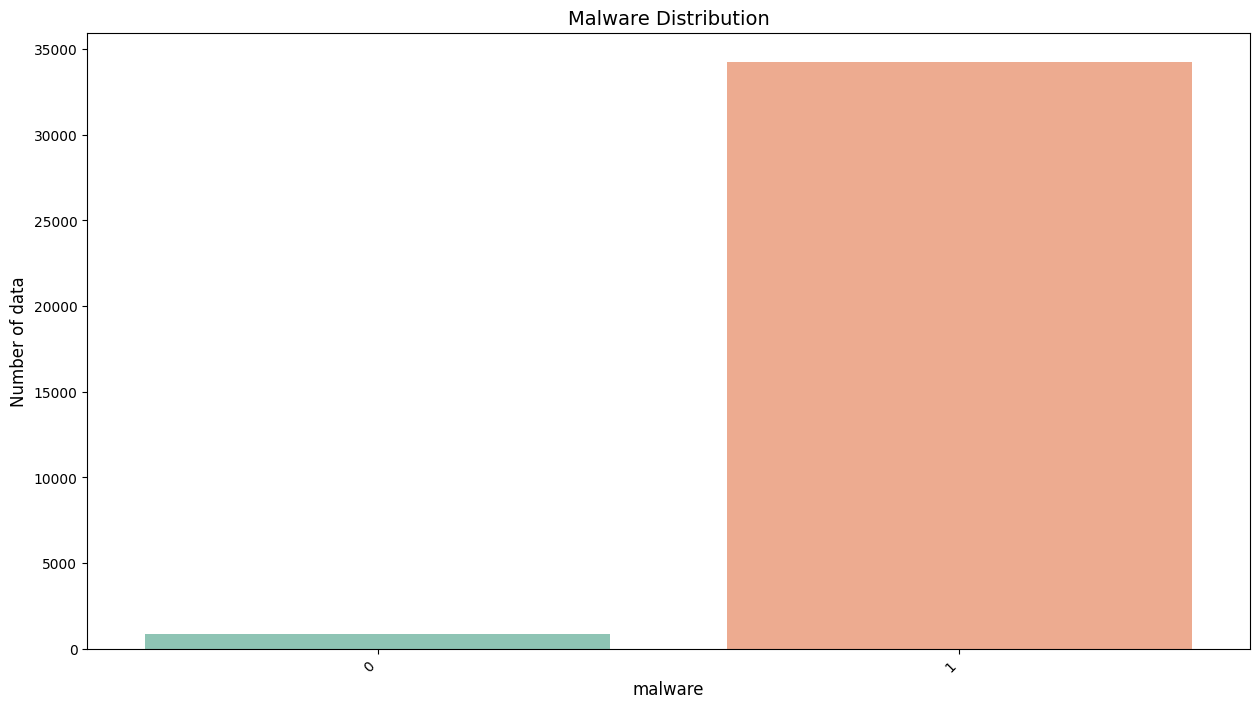

In [12]:
cnt_pro = train['malware'].value_counts()

plt.figure(figsize=(15,8))
ax = sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel('Number of data', fontsize=12)
plt.xlabel('malware', fontsize=12)
plt.title('Malware Distribution', fontsize=14)
plt.show()

**Malware Distribution Plot**

The bar plot illustrating the $\mathbf{Malware Distribution}$ confirms the severe class imbalance. The count of the $\mathbf{1}$ class (malware) dwarfs the count of the $\mathbf{0}$ class (goodware). This visual evidence underscores the necessity of implementing specific sampling techniques (like $\text{SMOTE}$) during the training pipeline to create a balanced learning environment, ensuring the $\text{MLP}$ can effectively distinguish the minority class patterns.

The foundational steps of cleaning, splitting, and analyzing the data confirm its high dimensionality (100 features) and its primary challenge: extreme class imbalance. The subsequent steps in the pipeline must now address these challenges to successfully train the $\text{MLP}$ classifier.

# Features Engineering

**Train and Test Split**

The initial step in feature engineering separates the data into $\mathbf{feature}$ sets ($\mathbf{X}$) and the $\mathbf{target}$ label ($\mathbf{y}$). The target variable, $\mathbf{malware}$, is isolated from the $100$ sequential API call features.

In [ ]:
x_train = train.drop('malware', axis=1) 
y_train = train['malware'] 
x_test = test.drop('malware', axis=1) 
y_test = test['malware'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35100, 100)
y_train shape: (35100,)
X_test shape: (8776, 100)
y_test shape: (8776,)


**Data Normailization (Standardization)**

The features, which represent encoded API calls, possess different scales, which can disproportionately influence the gradient descent process in models like $\text{MLP}$ (Multi-Layer Perceptron). To mitigate this, StandardScaler is applied, implementing $\mathbf{Z}$-score normalization. This process transforms the data such that each feature has a mean of approximately $\mathbf{0}$ and a standard deviation of $\mathbf{1}$. This ensures that all features contribute equally to the distance calculations and convergence speed during model training. It is critical that the scaler is $\mathbf{fit}$ only on the training data and then used to $\mathbf{transform}$ both the training and test sets, preventing data leakage from the test set into the training process.

In [ ]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [ ]:
x_train_std = pd.DataFrame(x_train_std, columns=x_train.columns)
x_test_std = pd.DataFrame(x_test_std, columns=x_test.columns)
x_train_std.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
count,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,...,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04
mean,-1.530400e-16,-1.220676e-16,-2.702492e-16,-1.805710e-16,-1.781418e-17,-6.498126e-17,7.530538e-17,8.502221e-18,-1.064802e-16,2.206529e-17,...,3.623566e-17,1.651860e-16,2.753100e-17,-1.615422e-16,1.595179e-16,2.200456e-16,1.388696e-16,1.046583e-16,2.672127e-17,-2.186285e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.862269e+00,-3.470570e+00,-3.065186e+00,-2.733193e+00,-2.630257e+00,-2.648494e+00,-3.068486e+00,-3.007622e+00,-2.137860e+00,-3.093614e+00,...,-1.988217e+00,-1.969644e+00,-2.092740e+00,-2.154170e+00,-2.345042e+00,-2.459406e+00,-1.906935e+00,-2.029966e+00,-2.138000e+00,-1.972789e+00
25%,-8.040650e-01,-6.510567e-01,-6.541849e-01,-1.050861e+00,-9.882581e-01,-8.687154e-01,-9.613328e-01,-6.112353e-01,-3.863419e-01,-9.417027e-01,...,-5.210352e-01,-9.350384e-01,-6.787004e-01,-6.150960e-01,-6.812561e-01,-8.005519e-01,-7.931117e-01,-7.483795e-01,-6.984123e-01,-1.048133e+00
50%,-8.040650e-01,4.767487e-01,2.053893e-01,3.827780e-01,-2.163783e-01,-2.450323e-01,2.920932e-02,2.435267e-01,-3.863419e-01,8.747213e-02,...,-6.894509e-03,-1.686636e-01,-1.398097e-02,-2.505786e-01,8.664514e-02,-2.074870e-02,-1.423383e-01,1.615471e-01,-5.859557e-02,-1.868092e-01
75%,9.551998e-01,4.767487e-01,4.989025e-01,7.485023e-01,1.215108e+00,1.002334e+00,8.036331e-01,6.251169e-01,9.759502e-01,7.611139e-01,...,1.021387e+00,1.095855e+00,1.049570e+00,1.085986e+00,7.123424e-01,9.433716e-01,7.837623e-01,8.407881e-01,8.611411e-01,8.771786e-01
max,2.158907e+00,1.571383e+00,3.308243e+00,1.714014e+00,1.664202e+00,2.006311e+00,2.442530e+00,1.632515e+00,2.443034e+00,2.594916e+00,...,1.849028e+00,1.938867e+00,1.605517e+00,1.977028e+00,2.006398e+00,1.879135e+00,1.922616e+00,1.891689e+00,1.940832e+00,1.903167e+00


**Dimensionality Reduction (PCA)**

**Principal Component Analysis (PCA)**

With $100$ distinct features, the dataset operates in a high-dimensional space. Principal Component Analysis ($\text{PCA}$) is used to reduce this dimensionality while preserving most of the variance within the data. $\text{PCA}$ achieves this by transforming the original correlated features into a smaller set of linearly uncorrelated variables called principal components ($\text{PC}$). By setting `n_components=2`, the $100$ features are projected onto a $2\text{D}$ space (PC1 and PC2), allowing for visual analysis of the underlying data structure and reducing computational load for the subsequent modeling step.

In [ ]:
pca = PCA(n_components=2) 

x_train = pca.fit_transform(x_train_std)
x_test = pca.transform(x_test_std)

**Before Oversampling Visualization**

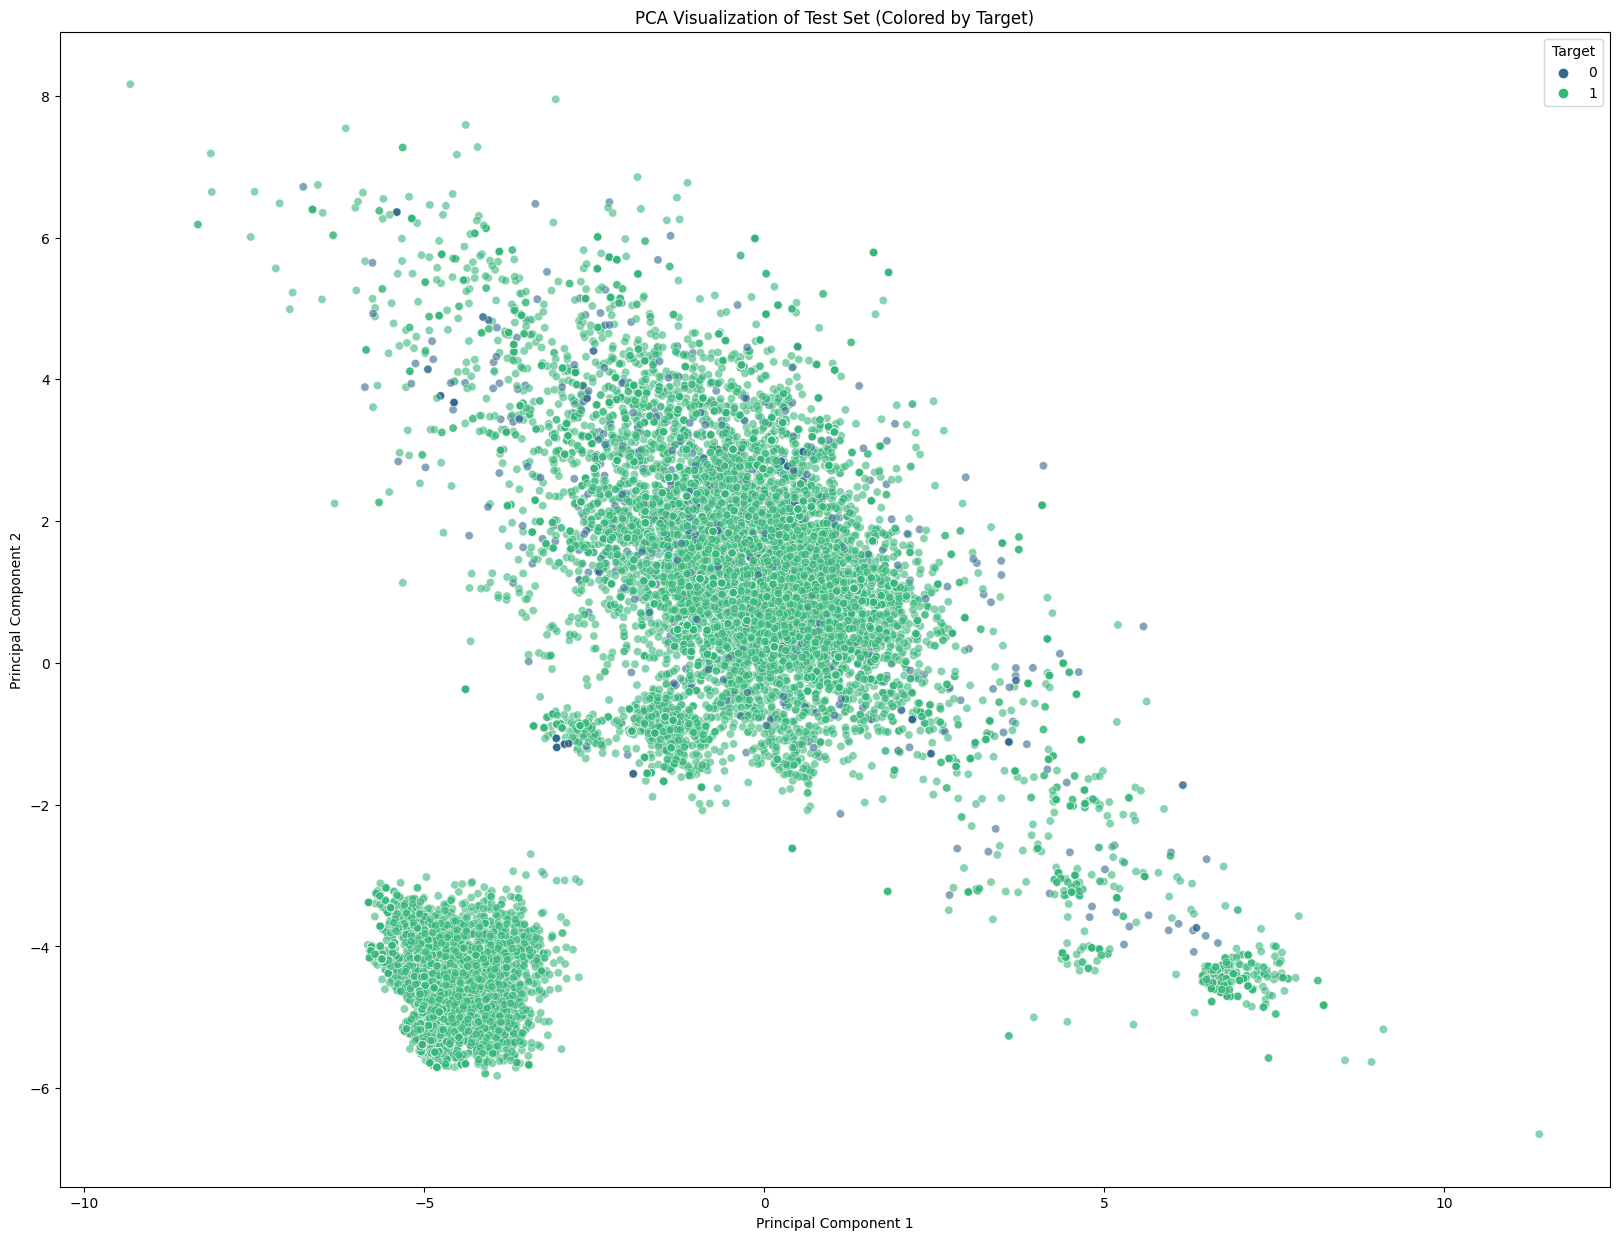

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

The scatter plot of the PCA-transformed data (PC1 vs. PC2) displays a high degree of overlap between the two target classes ($\mathbf{0}$ and $\mathbf{1}$). The vast majority of points, representing the majority class ($\mathbf{1}$), form a dense, centrally located cloud. The minority class ($\mathbf{0}$) is barely visible, scattered sparsely within and around this central mass, with a small, slightly more distinct cluster visible in the bottom-left quadrant. This visual evidence confirms the challenge of class imbalance and suggests that in this reduced $2\text{D}$ space, the two classes are not easily linearly separable.

**Oversampling (SMOTE)**

**Synthetic Minority Over-sampling Technique (SMOTE)**

The severe class imbalance observed earlier must be corrected before model training. The $\text{SMOTE}$ algorithm addresses this by generating synthetic samples for the minority class ($\mathbf{0}$). It works by selecting minority class examples that are close to each other in the feature space and drawing a line between them to create a new, artificial data point. This process balances the class distribution in the training set, achieving a $\mathbf{50:50}$ ratio (from $35,100$ samples to $68,494$ samples in total). This technique ensures the classifier is exposed to an equal number of examples from both classes, preventing it from favoring the majority class and improving the detection performance for the rare class.

In [ ]:
smote = SMOTE(random_state=42)
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
x_train, y_train = smote.fit_resample(x_train, y_train)

print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
y_train.value_counts(normalize=True)*100

Shape of original x_train: (35100, 2)
Shape of original y_train: (35100,)
Shape of original x_train: (68494, 2)
Shape of original y_train: (68494,)


malware
1    50.0
0    50.0
Name: proportion, dtype: float64

**After Oversampling Visualization**

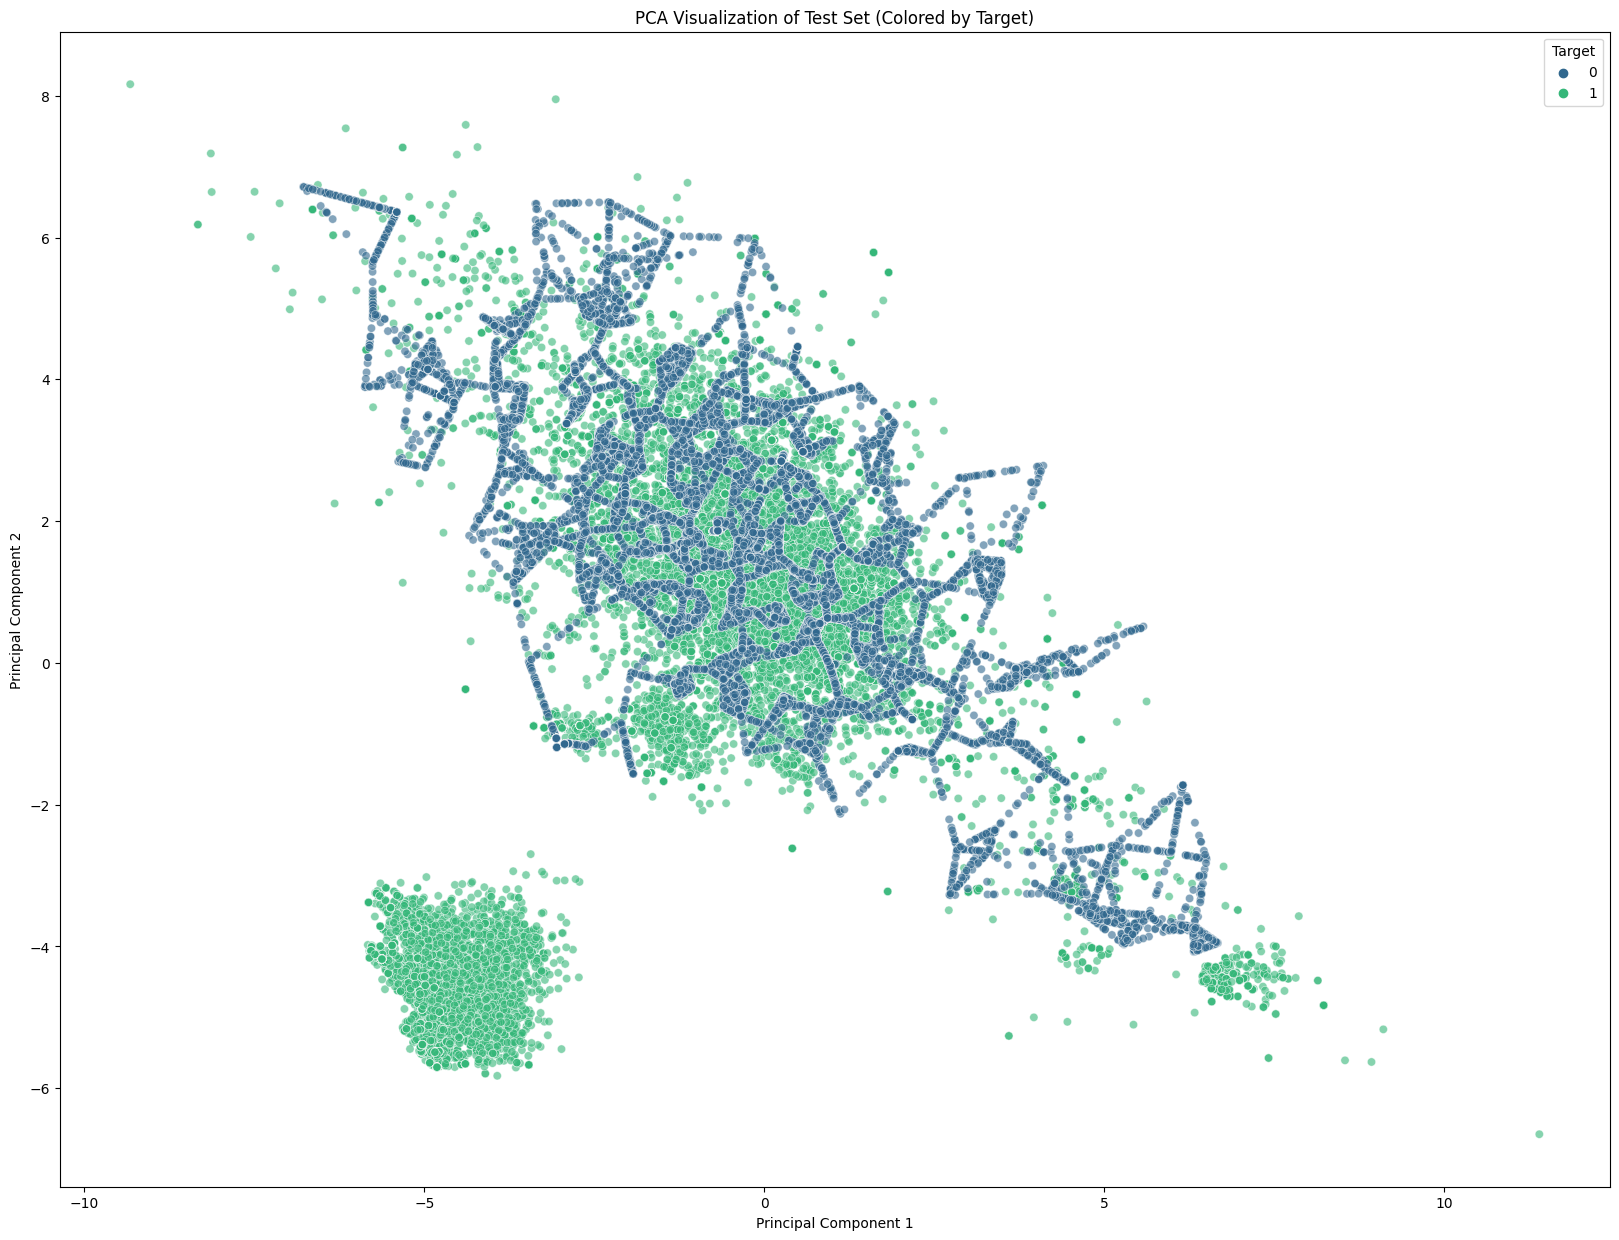

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Visualization Interpretation (After Oversampling)**

After applying $\text{SMOTE}$, the scatter plot shows a significant increase in the data points representing the minority class ($\mathbf{0}$). The plot now appears much denser, especially in the areas where the minority class samples were originally located. The synthetic points generated by $\text{SMOTE}$ connect the existing minority data points, creating lines and structure between them, which visually indicates the boundary-drawing process of the algorithm. This balanced dataset, though still showing overlap, provides the model with sufficient information on both classes to learn meaningful distinguishing features.

# Model Training

## Model Architecture and Model Training (Keras)

**Keras MLP Hyperparameters for Classification**

Hyperparameters are the configuration values that define the structure of the neural network and control the learning algorithm. They are set manually before training and are not learned from the data, unlike the model's internal parameters (weights and biases).

**Structural Hyperparameters (Architecture)**

These parameters dictate the capacity and form of the network layers:

- Number of Layers and Units: This controls the depth and width of the network. Layers define the model's depth, allowing it to learn hierarchical feature representations. Units (neurons) define the width of each layer, determining its $\mathbf{representational\ power}$. More units and layers increase complexity, which may require more data to prevent $\mathbf{overfitting}$.

- Activation Function: This non-linear function (e.g., $\mathbf{relu}$, $\mathbf{sigmoid}$, $\mathbf{softmax}$) is applied to a neuron's output. It is essential because it allows the model to map complex, non-linear relationships necessary for successful classification.
    - Parameters: In hidden layers, $\mathbf{relu}$ is common. For the classification output layer, $\mathbf{sigmoid}$ is used for a single-unit binary output, and $\mathbf{softmax}$ is used for a multi-unit output in multi-class problems.

- Weight Initializer: The strategy used to assign the initial random values to the weights before optimization begins. Proper initialization is critical to ensuring that the gradient signals remain stable—not too large, not too small—during backpropagation.
    - Parameters: Common schemes are `glorot_uniform`  (Xavier) or `he_uniform` , which automatically scales the initial weights based on the number of inputs to the layer.

**Training Hyperparameters (Optimization and Learning)**

These settings are defined during the `model.compile` and `model.fit` stages and guide the network's optimization process:

- Optimizer: The algorithm (e.g., $\mathbf{Adam}$, $\mathbf{RMSprop}$, $\mathbf{SGD}$) used to adjust the network's weights to minimize the loss function. It determines the weight update strategy using the calculated gradients.
    - Parameters: Optimizers often have internal parameters like $\mathbf{\beta 1}$ and $\mathbf{\beta 2}$ (in Adam) which control the decay rates of past gradients and squared gradients, respectively.
- Learning Rate: Controls the step size the optimizer takes down the slope of the loss function. A smaller rate guarantees more precise convergence but slows training; a larger rate is faster but risks missing the minimum or causing unstable training.
    - Parameters: This is typically a single floating-point value (e.g., $0.001$) passed when instantiating the optimizer.
- Loss Function: The objective function that measures the error between the model's prediction and the true label. The entire goal of training is to minimize this value.
    - Parameters: For classification, the function is `binary_crossentropy` for two classes or `categorical_crossentropy` (or `sparse_categorical_crossentropy`) for multiple classes.
- Epochs and Batch Size:
    - Epochs: The total number of times the model will iterate through the entire training dataset. This is a limit on the total learning duration.
    - Batch Size: The number of training samples processed in one forward and backward pass before the model's weights are updated. Smaller batches introduce beneficial noise and can improve `generalization`, while larger batches are more computationally efficient.

**Regularization and Control Hyperparameters**

These are used to manage the model's complexity and prevent the issue of $\mathbf{overfitting}$:

- Dropout Rate: A regularization technique where a specified fraction of neurons are randomly deactivated during each training step. This forces the remaining neurons to learn more robust features, preventing co-adaptation and improving the model's ability to generalize to new data.
    - Parameters: A floating-point value between $0$ and $1$ that represents the probability of a neuron being dropped (e.g., $0.2$ means $20%$ of neurons are deactivated).
- L1/L2 Regularization (`Kernel_Regularizer`): A penalty term added to the loss function based on the magnitude of the weight values. This discourages the weights from growing too large, leading to a simpler, more robust model.
    - Parameters: A regularization rate (a small floating-point value) controls the strength of the penalty. $\mathbf{L1}$ regularization encourages weights to be exactly zero (sparse models), while $\mathbf{L2}$ encourages weights to be small but non-zero.
- Patience (`tf.keras.callbacks.EarlyStopping`): A parameter that defines the number of epochs the model will wait for an improvement in the monitored metric (e.g., `val_loss`) before automatically stopping training. This is a crucial mechanism to prevent overfitting by halting the process at the optimal point.

**Model Architecture and Training**

The classification task is executed using a Multi-Layer Perceptron ($\text{MLP}$), a fundamental type of Artificial Neural Network ($\text{ANN}$). The architecture employs the Keras Sequential API and consists of two hidden $\mathbf{Dense}$ layers, each with $\mathbf{54}$ neurons and using the Rectified Linear Unit ($\text{ReLU}$) as the activation function. $\text{ReLU}$ is chosen for its computational efficiency and effectiveness in mitigating the vanishing gradient problem. The final layer is an output layer with a single neuron and a Sigmoid activation function, which maps the output value to a probability between $\mathbf{0}$ and $\mathbf{1}$, suitable for binary classification.

**Training**

- Loss Function and Optimizer: The model is compiled using `binary_crossentropy` as the loss function, which quantifies the distance between the predicted probability and the true binary label. The Adam optimizer is utilized for training, providing an efficient method for updating the network's weights during backpropagation, with a small learning rate of 0.0001 to ensure stable convergence.
- Early Stopping: To prevent overfitting, an Early Stopping callback is implemented. This mechanism monitors the validation loss and terminates training if no improvement is observed over 10 epochs (`patience=10`), thereby restoring the weights from the epoch that achieved the best performance. This ensures that the model generalizes well to unseen data.

In [ ]:
model = keras.Sequential([
    layers.Dense(64, input_shape=(x_train.shape[1],), activation='relu', name='hidden_layer'),
    layers.Dense(64, input_shape=(x_train.shape[1],), activation='relu', name='hidden_layer_1'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(x_train, y_train, epochs=200, verbose=1, validation_split=0.2, callbacks=[early_stopping])

print("\nTraining complete.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-18 01:45:47.629119: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6556 - loss: 0.5735 - val_accuracy: 0.5173 - val_loss: 0.7671
Epoch 2/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7026 - loss: 0.5284 - val_accuracy: 0.5197 - val_loss: 0.7210
Epoch 3/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7057 - loss: 0.5184 - val_accuracy: 0.5050 - val_loss: 0.7102
Epoch 4/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7180 - loss: 0.5110 - val_accuracy: 0.4919 - val_loss: 0.7026
Epoch 5/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7293 - loss: 0.5021 - val_accuracy: 0.4831 - val_loss: 0.7032
Epoch 6/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7309 - loss: 0.4977 - val_accuracy: 0.4675 - val_loss: 0.7003
Epoch 7/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7316 - loss: 0.4946 - val_accuracy: 0.4819 - val_loss: 0.6896
Epoch 8/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7294 - loss: 0

**Training History (Keras)**

Final Training Loss: 0.3998
Final Training Accuracy: 0.7706

Learned Weights (Output Layer): [ 0.0046989  -0.06185126  0.10509551 ...  0.34091002 -0.16413067
 -0.17880642]
Learned Bias (Output Layer): 0.2060
2141/2141 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Sample Predictions (from training data):
  Input: [ 8.22433309 -4.82968463], Actual: 1, Predicted (proba): 0.9985, Predicted (binary): 1
  Input: [0.12432038 0.8807252 ], Actual: 1, Predicted (proba): 0.7406, Predicted (binary): 1
  Input: [ 8.22433309 -4.82968463], Actual: 1, Predicted (proba): 0.9985, Predicted (binary): 1
  Input: [0.15724503 0.27817815], Actual: 1, Predicted (proba): 0.6930, Predicted (binary): 1
  Input: [1.3193617  1.05192699], Actual: 1, Predicted (proba): 0.8678, Predicted (binary): 1
  Input: [-1.57739282  3.20050721], Actual: 1, Predicted (proba): 0.4870, Predicted (binary): 0
  Input: [-0.78755543  3.21831199], Actual: 1, Predicted (proba): 0.5581, Predicted (binary): 1
  Input: [-1.85247028  3.80433921], Actua

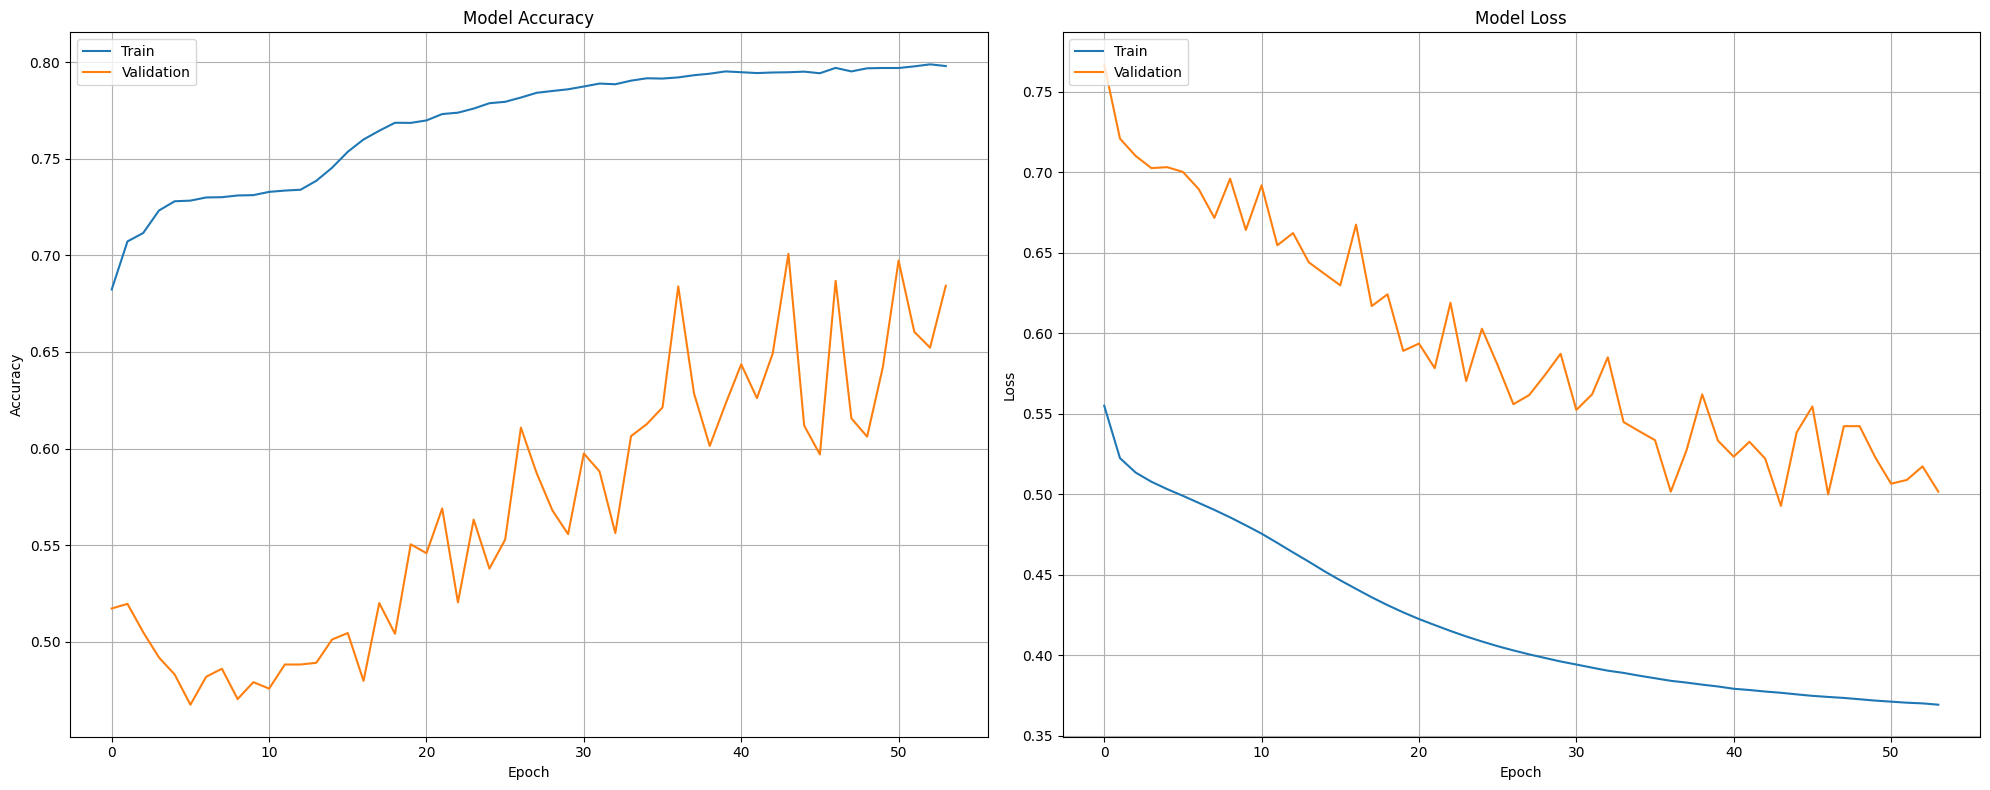

In [ ]:
loss, accuracy = model.evaluate(x_train, y_train, verbose=0)
print(f"Final Training Loss: {loss:.4f}")
print(f"Final Training Accuracy: {accuracy:.4f}")

weights, bias = model.layers[1].get_weights()
print(f"\nLearned Weights (Output Layer): {weights.flatten()}")
print(f"Learned Bias (Output Layer): {bias[0]:.4f}")

y_pred_proba = model.predict(x_train).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print("\nSample Predictions (from training data):")
for i in range(min(10, len(x_train))): 
    print(f"  Input: {x_train[i]}, Actual: {y_train[i]}, Predicted (proba): {y_pred_proba[i]:.4f}, Predicted (binary): {y_pred[i]}")

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

**Model Training History**

The plot displaying Model Accuracy shows that both the training accuracy and validation accuracy generally trend upwards, demonstrating that the model successfully learns from the data. The Validation Accuracy consistently lags behind the Training Accuracy, which is normal, but the gap remains manageable, suggesting the $\text{SMOTE}$ oversampling technique successfully created a balanced and learnable dataset without leading to severe overfitting during the early stages.

The Model Loss plot shows a steady decrease in both training loss and validation loss, confirming that the $\text{Adam}$ optimizer is successfully minimizing the loss function. Training stopped after $\mathbf{54}$ epochs (with the best weights restored from Epoch 44) due to the $\text{Early Stopping}$ mechanism, indicating that the model had reached its optimal performance point on the validation set, preventing further fine-tuning that might have specialized the model too much to the training data. The final training accuracy reached approximately $77.06%$, with a training loss of $0.3998$.

**Decision Boundary Visualization (Keras)**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


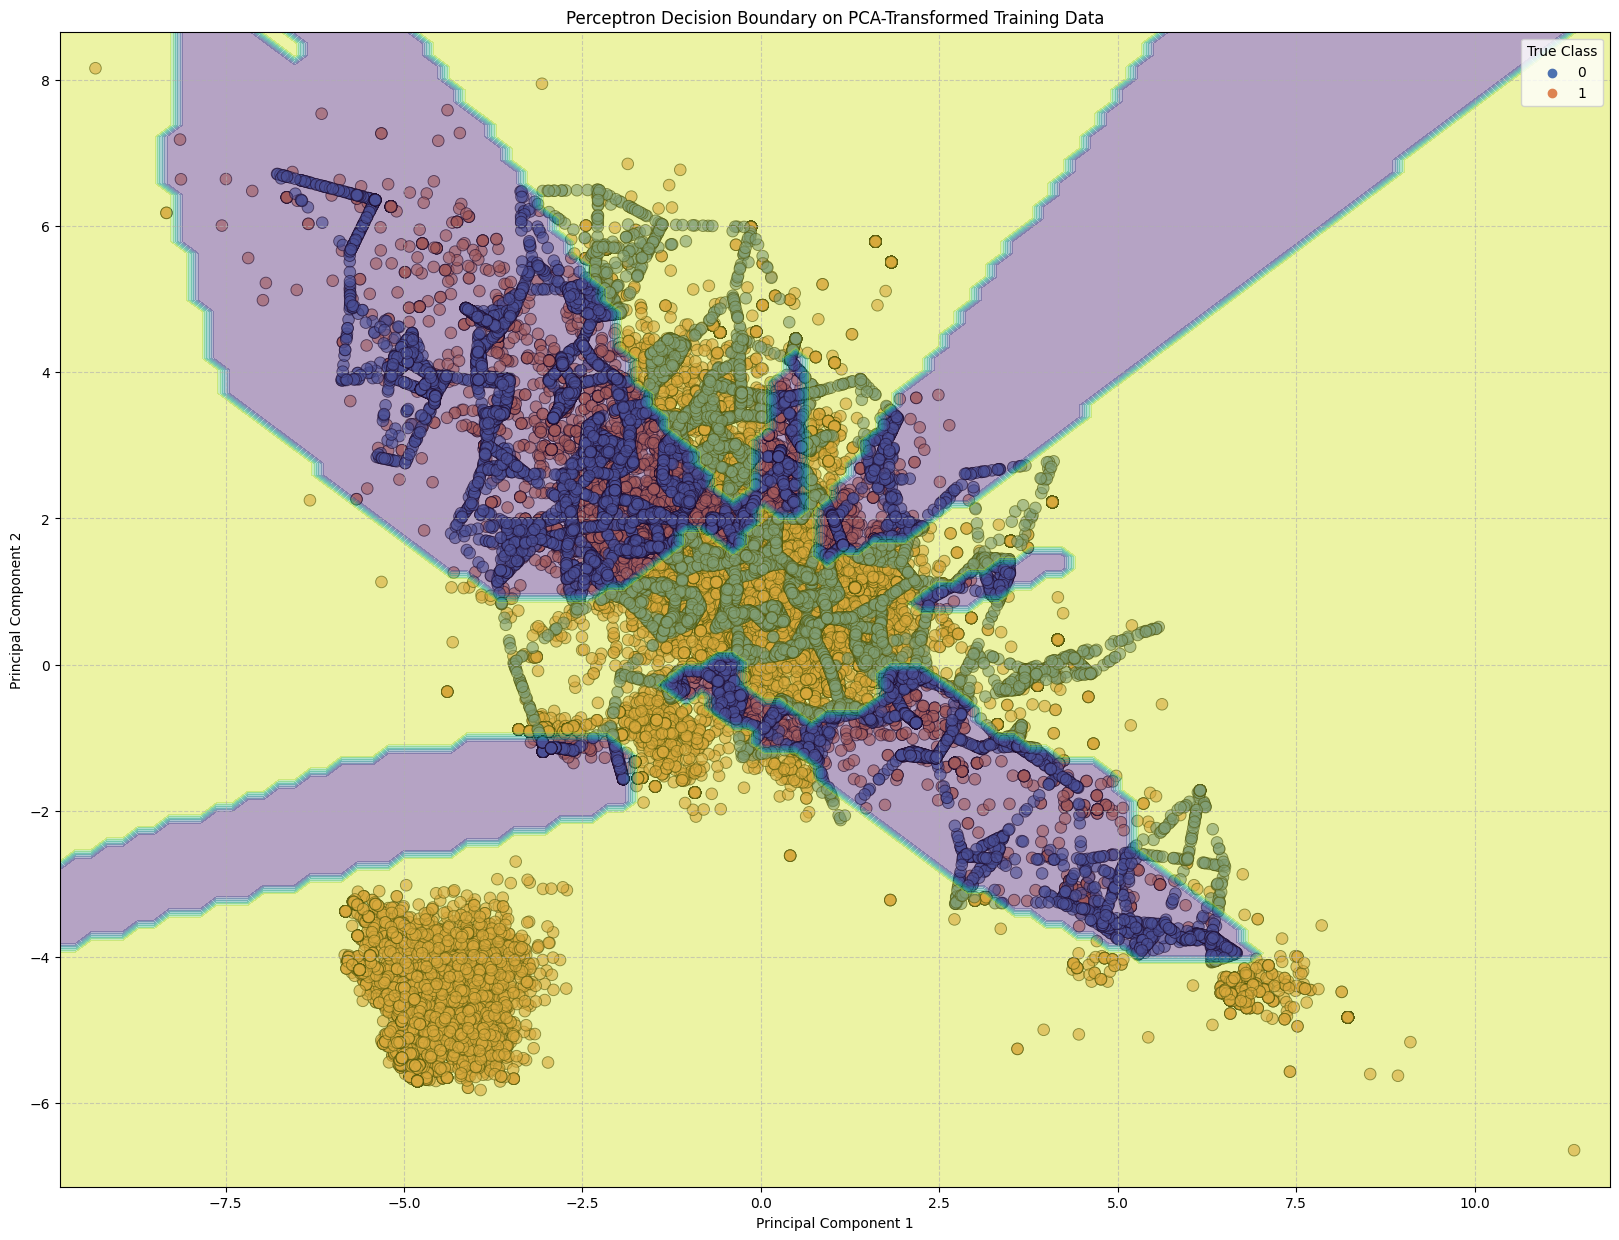

In [ ]:
plot_data_train = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data_train,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z_proba = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=1).flatten()
Z = (Z_proba > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Decision Boundary**

The scatter plot illustrating the Decision Boundary on the $2\text{D}$ PCA-transformed data reveals the complexity of the learned separation. The boundary is non-linear due to the presence of the hidden layers and the $\text{ReLU}$ activation functions, confirming that the $\text{MLP}$ can find complex decision surfaces.

The boundary is visually effective in separating the two classes, $\mathbf{0}$ (goodware) and $\mathbf{1}$ (malware), which had significant overlap in the original PCA visualization. The decision boundary creates a complex curve that attempts to enclose the majority of the $\mathbf{1}$ class points while separating the $\mathbf{0}$ class points. This demonstrates the network's ability to utilize the synthetic data generated by $\text{SMOTE}$ to establish a more robust and equitable classification boundary between the minority and majority classes. The complex shape of the boundary is a direct result of the model's structure and the non-linear relationship between the two principal components.

## Model Architecture and Model Training (TensFlow custom functions)

**Hyperparameters in a TensorFlow Multi-Layer Perceptron ($\text{MLP}$)**

Hyperparameters are the configuration values that define the structure of the neural network and control the learning algorithm. They are set manually before training begins and are not learned from the data, unlike the model's internal parameters (weights and biases).

**Structural Hyperparameters (Architecture)**

These parameters dictate the capacity and form of the network layers:

**Number of Layers and Units**
- Layers: Refers to the depth of the network, controlling the complexity of features the model can learn. More layers enable hierarchical feature extraction.
- Units (Neurons): The width of each layer. A higher number of units increases the layer's representational power, allowing it to capture finer details, but may require more data and computation time.

Activation Function: This is a non-linear function applied to the output of a neuron. It is essential because it allows the model to map complex, non-linear relationships necessary for classification.
- Parameters: Common choices include `tf.nn.relu` (Rectified Linear Unit), which introduces sparsity, and `tf.nn.sigmoid` (used for binary output) or `tf.nn.softmax` (used for multi-class output), which converts scores into probabilities.

Weight Initializer: The method used to assign the initial random values to the weights before optimization starts. Proper initialization ensures that the gradient signals do not vanish or explode during the critical early stages of training.
- Parameters: Common schemes are `glorot_uniform` (Xavier) or `he_uniform`, which automatically scale the initial weights based on the number of inputs and outputs of the layer.

**Training Hyperparameters (Optimization and Learning)**

These settings are defined during the `model.compile` and `model.fit` stages and control how the model learns:

Optimizer: The specific algorithm used to adjust the network's weights to minimize the loss function. It determines the direction and magnitude of the updates based on the gradient.
- Parameters: Popular choices include $\mathbf{Adam}$, which adapts the learning rate for each weight, often performing well out-of-the-box. Others are $\mathbf{RMSprop}$ and $\mathbf{SGD}$ (Stochastic Gradient Descent).

Learning Rate: Controls the step size the optimizer takes down the slope of the loss function. A smaller rate guarantees more precise convergence but slows training; a larger rate speeds up convergence but risks overshooting the optimal minimum.
- Parameters: Often set as a single floating-point value (e.g., $0.001$) within the optimizer configuration (`learning_rate`).

Loss Function: The measure of error between the model's predicted output and the true target value. Minimizing this value is the entire objective of the training process.
- Parameters: For classification, the function is `binary_crossentropy` for two classes or `categorical_crossentropy` (or `sparse_categorical_crossentropy`) for multiple classes.

Epochs and Batch Size:
- Epochs: The total number of times the model will iterate through the entire training dataset.
- Batch Size: The number of training samples processed in one forward and backward pass before the model's weights are updated. Smaller batches can introduce beneficial noise and improve generalization, while larger batches are more computationally efficient.

**Regularization and Control Hyperparameters**

These are used to manage the model's complexity and prevent the issue of overfitting:

Dropout Rate: A regularization technique where a fraction of neurons in a layer are randomly ignored (set to zero) during each training step. This forces the remaining neurons to learn more robust features, preventing co-adaptation and improving the model's ability to generalize to new data.
- Parameters: A floating-point value between $0$ and $1$ that represents the probability of a neuron being dropped (e.g., $0.2$ means $20%$ of neurons are deactivated).

L1/L2 Regularization (`Kernel_Regularizer): A penalty term added to the loss function that is based on the magnitude of the weight values. This discourages the weights from growing too large, leading to a simpler, more robust model.
- Parameters: $\mathbf{L1}$ regularization encourages weights to be exactly zero (sparse models), while $\mathbf{L2}$ encourages weights to be small but non-zero. The strength of the penalty is controlled by a regularization rate (a small floating-point value).

Patience (`tf.keras.callbacks.EarlyStopping`): A parameter within the $\mathbf{EarlyStopping}$ callback that defines the number of epochs to wait for an improvement in the monitored metric (e.g., `val_loss`) before automatically stopping training. This is a practical and essential way to prevent overfitting by stopping optimization at the optimal generalization point.

**Custom Layer Architecture and Training Concepts**

This task implements a Multi-Layer Perceptron ($\text{MLP}$) using a custom $\text{Keras}$ layer, $\mathbf{CustomDenseLayer}$, built directly upon the $\mathbf{TensorFlow}$ framework. This approach provides deep control over the network's foundational operations, mimicking the functionality of a standard $\mathbf{Dense}$ layer.

**Custom Layer Implementation**

The custom layer relies on three core methods:

- `__init__`: Initializes the layer's parameters, specifically the number of $\mathbf{units}$ (neurons) and the $\mathbf{activation}$ function ($\text{ReLU}$ or $\text{Sigmoid}$).
- `build`: This method is called once the layer receives its input shape. It is responsible for creating and registering the layer's trainable parameters: the $\mathbf{kernel}$ (weight matrix) and the $\mathbf{bias}$ vector. These weights are initialized using `glorot_uniform`, a standard approach for maintaining consistent variance during forward propagation.
- `call`: This defines the layer's forward pass logic. It computes the dot product of the input tensor and the $\mathbf{kernel}$ ($\mathbf{inputs} \cdot \mathbf{kernel}$), adds the $\mathbf{bias}$ ($\mathbf{inputs} \cdot \mathbf{kernel} + \mathbf{bias}$), and finally applies the specified $\mathbf{activation}$ function.

**Training Strategy**

The overall network structure is identical to the standard $\text{MLP}$ model, featuring two hidden layers (64 units, $\text{ReLU}$) and an output layer (1 unit, $\text{Sigmoid}$) for binary classification. The model is trained using the $\mathbf{Adam}$ optimizer with a learning rate of $\mathbf{0.0001}$ and the `binary_crossentropy` loss function. Early Stopping is once again employed, monitoring the validation loss over $\mathbf{10}$ epochs of patience to select the best performing weights and prevent overfitting, leading to termination at Epoch 32.

In [ ]:
class CustomDenseLayer(layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super(CustomDenseLayer, self).__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super(CustomDenseLayer, self).build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.kernel) + self.bias
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super(CustomDenseLayer, self).get_config()
        config.update({
            'units': self.units,
            'activation': keras.activations.serialize(self.activation)
        })
        return config

model = keras.Sequential([
    CustomDenseLayer(64, activation='relu', name='custom_hidden_layer_1'),
    CustomDenseLayer(64, activation='relu', name='custom_hidden_layer_2'),
    CustomDenseLayer(1, activation='sigmoid', name='custom_output_layer')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\nStarting training...")
history = model.fit(x_train, y_train, epochs=200, verbose=1, validation_split=0.2, callbacks=[early_stopping])

print("\nTraining complete.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_hidden_layer_1           │ ?                      │   0 (unbuilt) │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_hidden_layer_2           │ ?                      │   0 (unbuilt) │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_output_layer             │ ?                      │   0 (unbuilt) │
│ (CustomDenseLayer)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6296 - loss: 0.6069 - val_accuracy: 0.5474 - val_loss: 0.7100
Epoch 2/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7041 - loss: 0.5278 - val_accuracy: 0.5281 - val_loss: 0.7037
Epoch 3/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7079 - loss: 0.5161 - val_accuracy: 0.5055 - val_loss: 0.7107
Epoch 4/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7257 - loss: 0.5075 - val_accuracy: 0.5148 - val_loss: 0.6798
Epoch 5/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7262 - loss: 0.5032 - val_accuracy: 0.5013 - val_loss: 0.6827
Epoch 6/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7244 - loss: 0.4959 - val_accuracy: 0.5038 - val_loss: 0.6807
Epoch 7/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7258 - loss: 0.4909 - val_accuracy: 0.4810 - val_loss: 0.6838
Epoch 8/200
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accu

**Training History (TensorFlow)**

Final Training Loss: 0.4368
Final Training Accuracy: 0.7426

Learned Weights (Output Layer): [ 0.03687103 -0.01504518 -0.06035135 ...  0.4985459   0.24278243
  0.04418992]
Learned Bias (Output Layer): 0.1344
2141/2141 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Sample Predictions (from training data):
  Input: [ 8.22433309 -4.82968463], Actual: 1, Predicted (proba): 0.9761, Predicted (binary): 1
  Input: [0.12432038 0.8807252 ], Actual: 1, Predicted (proba): 0.7130, Predicted (binary): 1
  Input: [ 8.22433309 -4.82968463], Actual: 1, Predicted (proba): 0.9761, Predicted (binary): 1
  Input: [0.15724503 0.27817815], Actual: 1, Predicted (proba): 0.6895, Predicted (binary): 1
  Input: [1.3193617  1.05192699], Actual: 1, Predicted (proba): 0.7295, Predicted (binary): 1
  Input: [-1.57739282  3.20050721], Actual: 1, Predicted (proba): 0.5061, Predicted (binary): 1
  Input: [-0.78755543  3.21831199], Actual: 1, Predicted (proba): 0.5921, Predicted (binary): 1
  Input: [-1.85247028  3.80433921], Actua

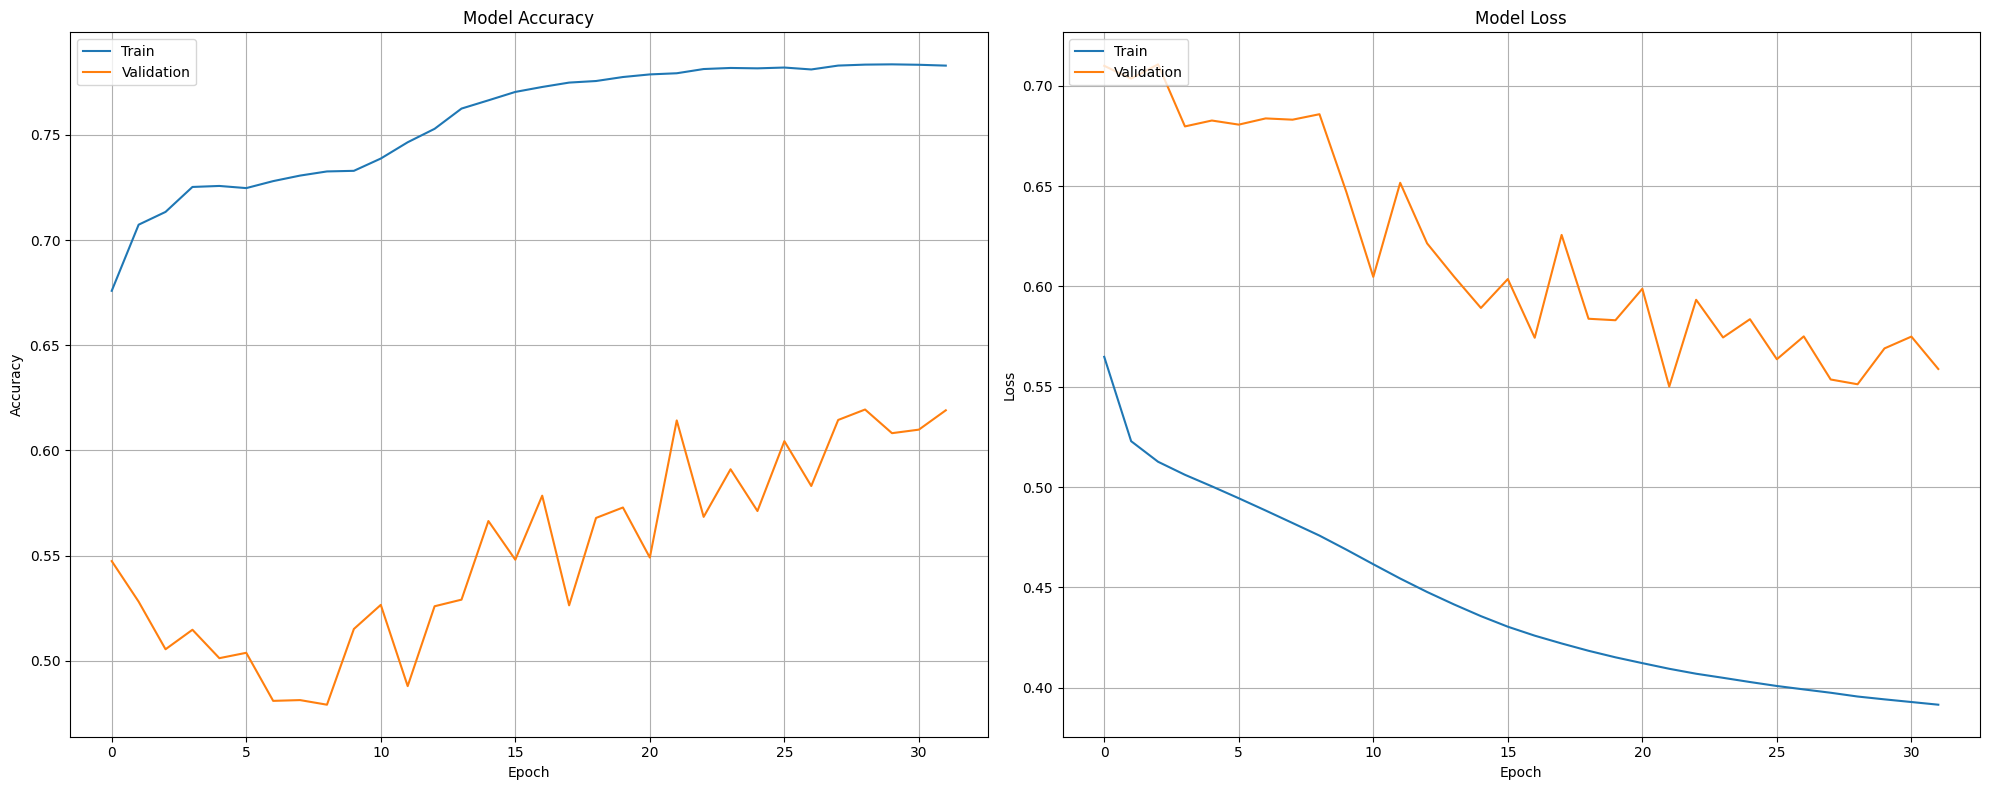

In [ ]:
loss, accuracy = model.evaluate(x_train, y_train, verbose=0)
print(f"Final Training Loss: {loss:.4f}")
print(f"Final Training Accuracy: {accuracy:.4f}")

weights, bias = model.layers[1].get_weights()
print(f"\nLearned Weights (Output Layer): {weights.flatten()}")
print(f"Learned Bias (Output Layer): {bias[0]:.4f}")

y_pred_proba = model.predict(x_train).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print("\nSample Predictions (from training data):")
for i in range(min(10, len(x_train))): 
    print(f"  Input: {x_train[i]}, Actual: {y_train[i]}, Predicted (proba): {y_pred_proba[i]:.4f}, Predicted (binary): {y_pred[i]}")

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

**Model Training History**

The plot of Model Accuracy shows that the training process successfully reduced the gap between the Training and Validation curves compared to the non-custom $\text{MLP}$ (previous run), suggesting this run converged to a more robust, generalizable solution. The validation accuracy rises steadily until the $\text{Early Stopping}$ condition is met.

The Model Loss plot confirms this convergence. Both training and validation loss decrease, with the lowest validation loss being achieved at Epoch 29 (Validation Loss: $\mathbf{0.5513}$). The training stopped at Epoch 32, restoring the best weights from Epoch 22. The final calculated training accuracy and loss are $74.26%$ and $0.4368$, respectively, which represents a slight improvement in performance over the previous model that used standard $\text{Keras}$ layers. This indicates the custom implementation performs comparably to the built-in layers while offering the flexibility of low-level modification.

**Decision Boundary Visualization (TensFlow custom functions)**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


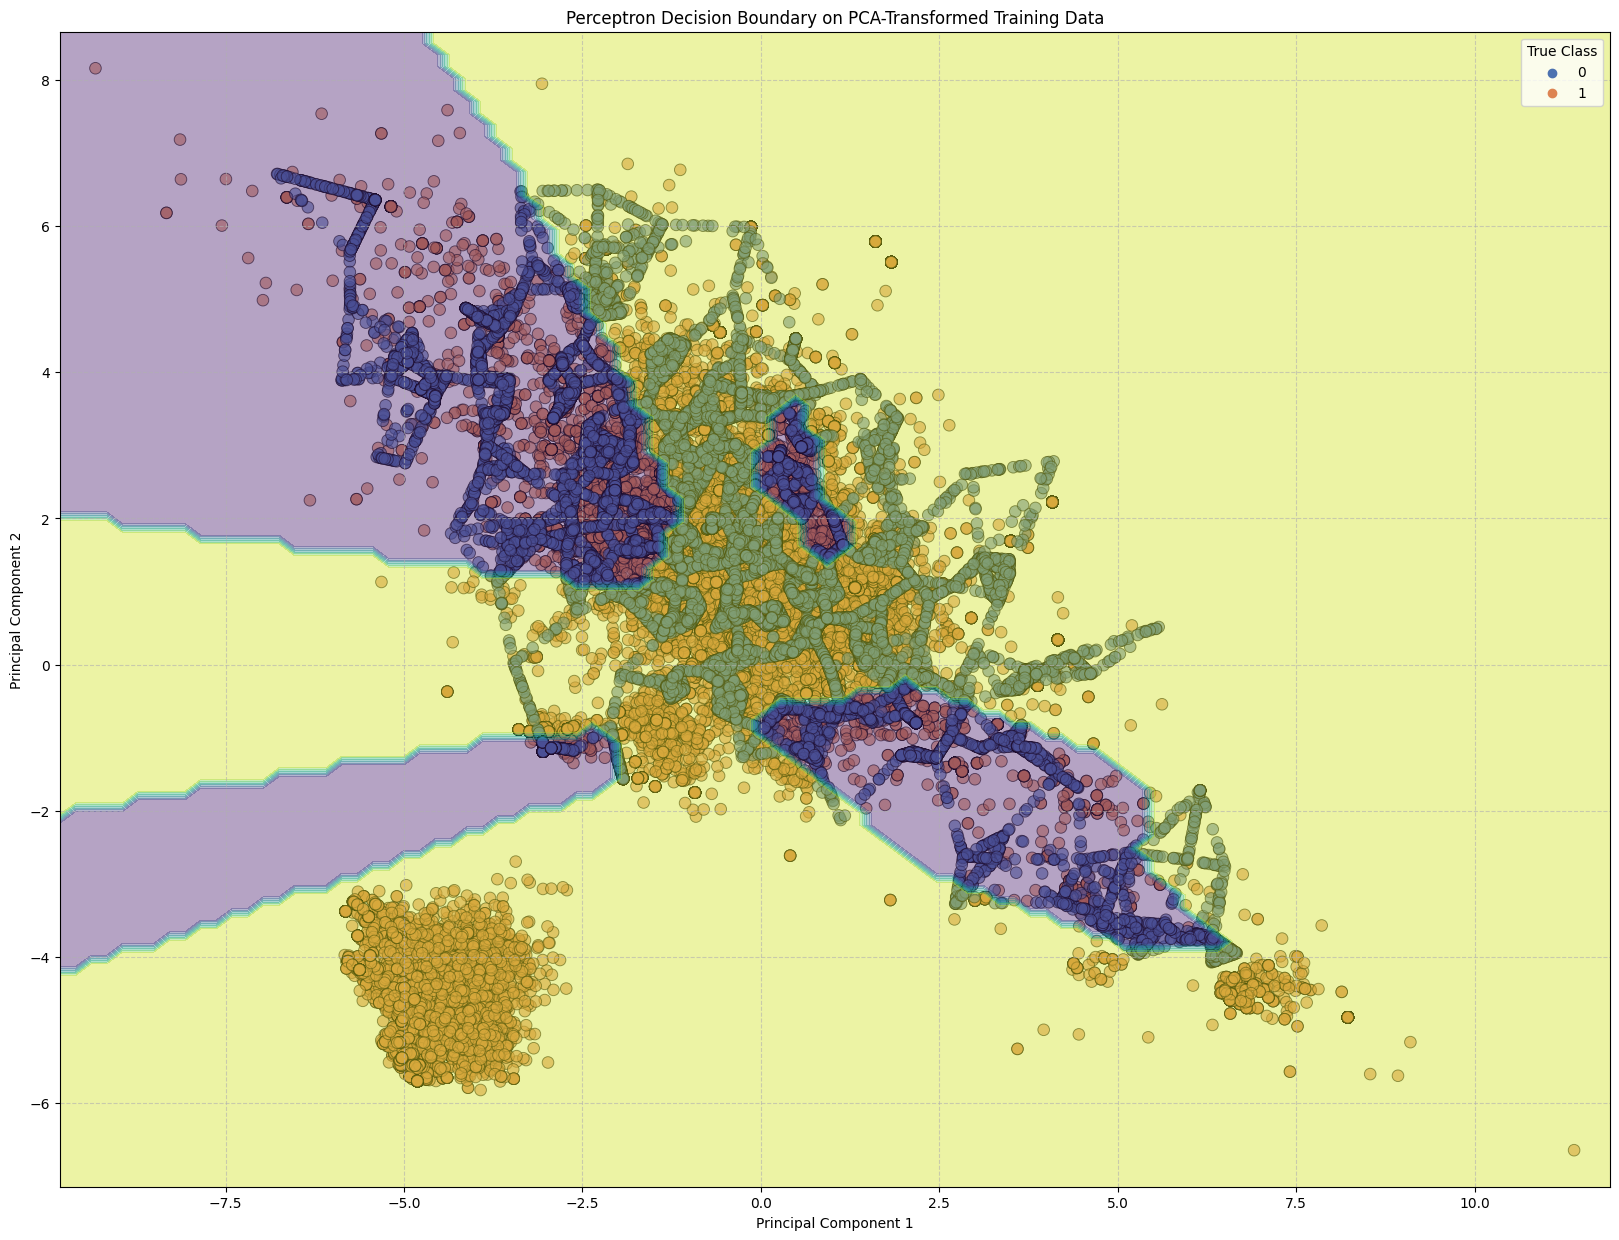

In [ ]:
plot_data_train = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data_train,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z_proba = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=1).flatten()
Z = (Z_proba > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Decision Boundary**

The visualization of the Decision Boundary on the $2\text{D}$ PCA features shows a complex, non-linear separation curve, characteristic of a deep network that has learned intricate patterns. The custom $\text{MLP}$ successfully divides the two classes (Class $\mathbf{0}$ and Class $\mathbf{1}$) in the feature space. The boundary's shape is consistent with the model's objective to maximize the separation margin between the clusters, demonstrating that the custom layers effectively performed the necessary feature transformations to achieve classification. The learned weights and biases enable this complex mapping, providing a clear visual representation of the model's non-linear classification capability.

# Model Evaluation

Model evaluation involves determining the classification performance of the trained neural network on unseen data, specifically the `x_test` set. Since the model was trained for binary classification, the evaluation relies on a set of critical metrics derived from the Confusion Matrix.

**Classification Metrics**

The Confusion Matrix is the foundational tool, mapping four outcomes:

- True Positive ($\mathbf{TP}$): Correctly predicted positive instances.
- True Negative ($\mathbf{TN}$): Correctly predicted negative instances.
- False Positive ($\mathbf{FP}$): Incorrectly predicted positive instances (Type I error).
- False Negative ($\mathbf{FN}$): Incorrectly predicted negative instances (Type II error).

From these, aggregate metrics are calculated:

- $\mathbf{Accuracy}$: The overall proportion of correct predictions ($\mathbf{(TP + TN) / Total}$).
- $\mathbf{Precision}$: Of all predicted positive cases, the proportion that were actually positive ($\mathbf{TP / (TP + FP)}$). High precision minimizes $\mathbf{FP}$.
- $\mathbf{Recall}$ (Sensitivity): Of all actual positive cases, the proportion that were correctly identified ($\mathbf{TP / (TP + FN)}$). High recall minimizes $\mathbf{FN}$.
- $\mathbf{F1-score}$: The harmonic mean of Precision and Recall, providing a balanced measure.

AUC-ROC (Area Under the Receiver Operating Characteristic Curve): Measures the model's ability to discriminate between positive and negative classes across all possible classification thresholds. A value closer to $1.0$ indicates perfect separation.

**Precision-Recall and ROC Curves**

These visualizations analyze the trade-off between critical metrics at various decision thresholds, which is crucial for models dealing with imbalanced datasets, as indicated by the class support counts.

- The Precision-Recall Curve plots Precision versus Recall. High performance is indicated by curves that hug the top-right corner, signifying high precision maintained even at high recall. It is preferred for highly skewed datasets.
- The ROC Curve plots the True Positive Rate ($\mathbf{Recall}$) against the False Positive Rate ($\mathbf{FPR}$). The closer the curve is to the top-left corner, the better the model's performance.

**Classification reports**

In [ ]:
y_pred_proba_test = model.predict(x_test, verbose=0).flatten()
y_pred_test = (y_pred_proba_test > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred_test, average='macro', zero_division=1)
f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=1)

roc_auc = roc_auc_score(y_test, y_pred_proba_test)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, zero_division=1))

Confusion Matrix:
[[ 133   93]
 [1130 7420]]
Accuracy: 0.861
Precision: 0.546
Recall: 0.728
F1-score: 0.551
AUC-ROC: 0.864

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.59      0.18       226
           1       0.99      0.87      0.92      8550

    accuracy                           0.86      8776
   macro avg       0.55      0.73      0.55      8776
weighted avg       0.96      0.86      0.90      8776



**Confusion metrix**

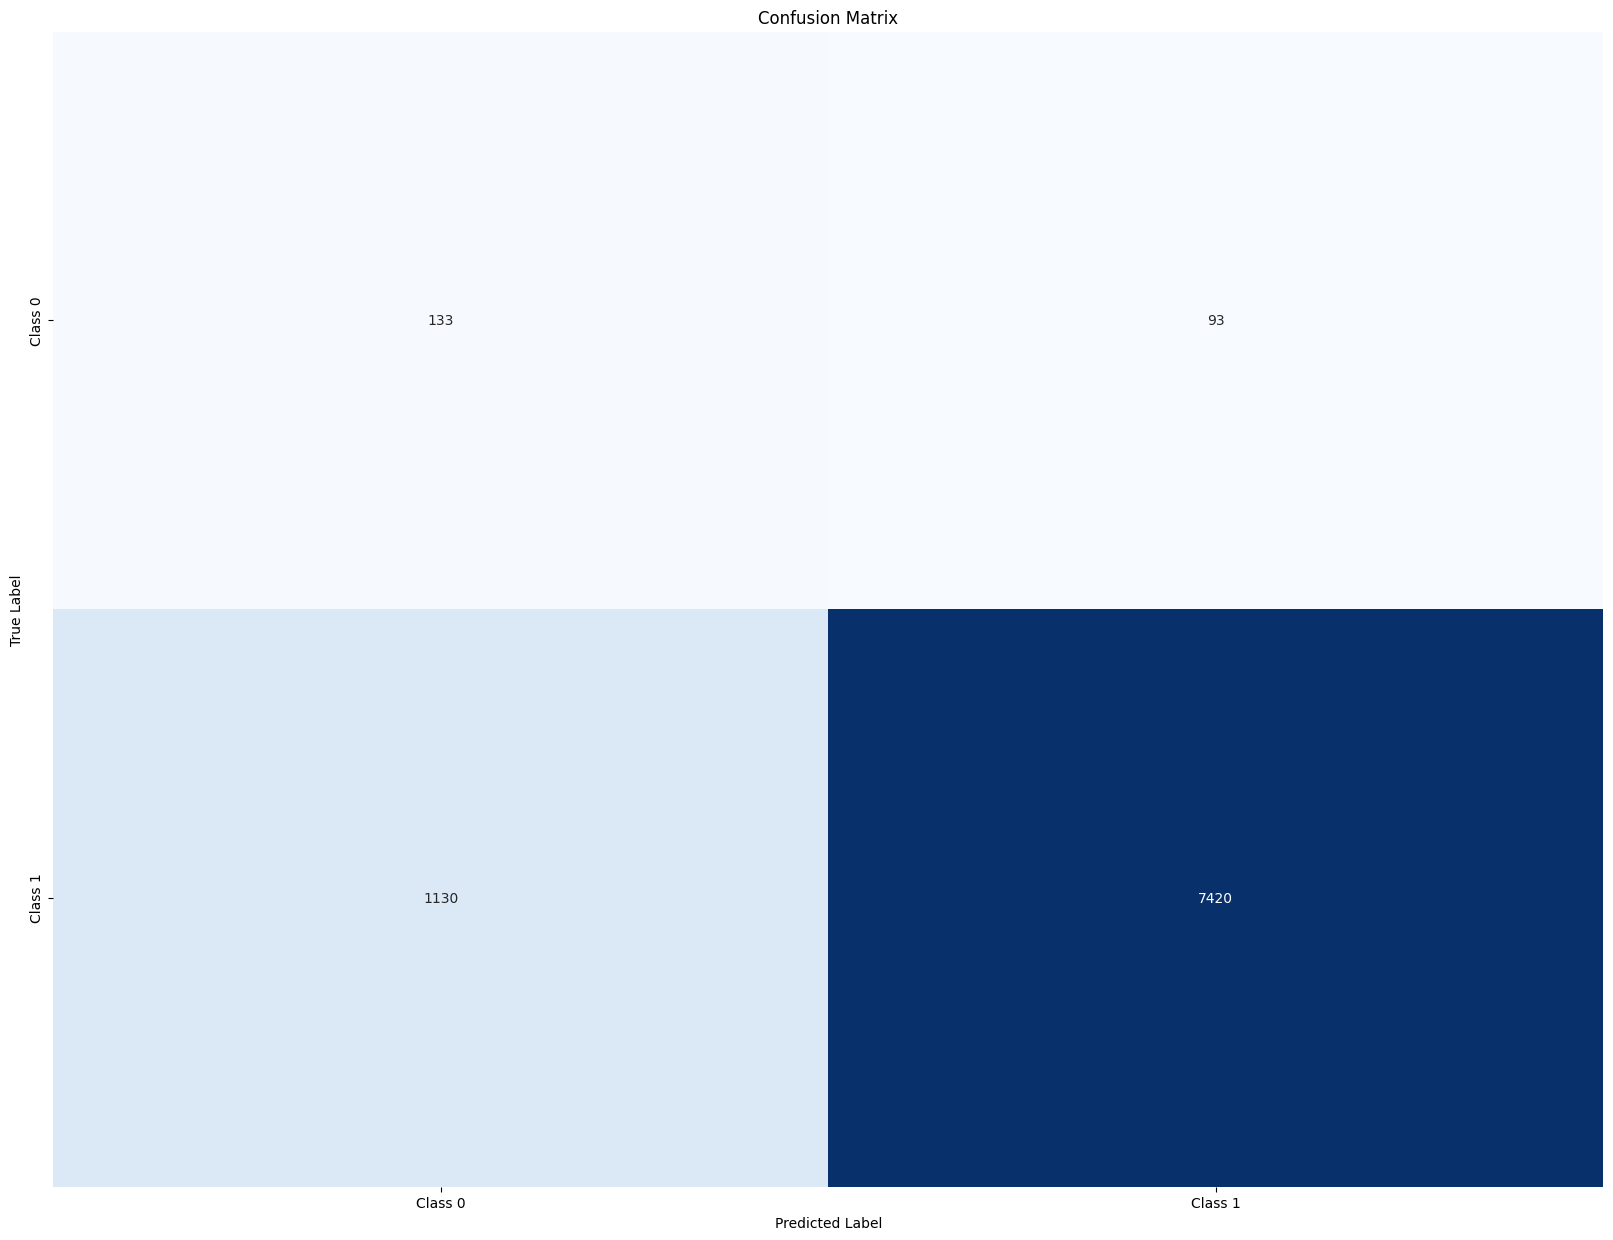

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Confusion Matrix and Classification Report**

The Confusion Matrix shows a significant class imbalance, with $\mathbf{8550}$ true instances of Class $\mathbf{1}$ and only $\mathbf{226}$ of Class $\mathbf{0}$ in the test set.
- Class 1 (Majority Class) Performance: The model performs exceptionally well on the majority class, achieving $\mathbf{7420}$ True Positives ($\mathbf{TP}$) and a Recall of $\mathbf{0.87}$ and Precision of $\mathbf{0.99}$.
- Class 0 (Minority Class) Performance: The model struggles significantly with the minority class. It only correctly identified $\mathbf{133}$ True Negatives ($\mathbf{TN}$) while misclassifying $\mathbf{93}$ instances as Class $\mathbf{1}$ (False Negatives). This results in a poor Precision of $\mathbf{0.11}$ for Class $\mathbf{0}$, meaning $90\%$ of what the model predicts as Class $\mathbf{0}$ is incorrect.

**Overall Metrics**

The overall Accuracy is high ($\mathbf{0.86}$), but this is deceptive due to class imbalance. The macro average $\mathbf{F1-score}$ ($\mathbf{0.55}$), which treats both classes equally, provides a more realistic view of the model's struggle to classify the minority class. The AUC-ROC ($\mathbf{0.864}$) is strong, suggesting the model's probability scores are generally well-ordered, even if the $\mathbf{0.5}$ threshold is suboptimal for the minority class.

**Precision-Recall Curve**


--- Plotting Precision-Recall Curve ---
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


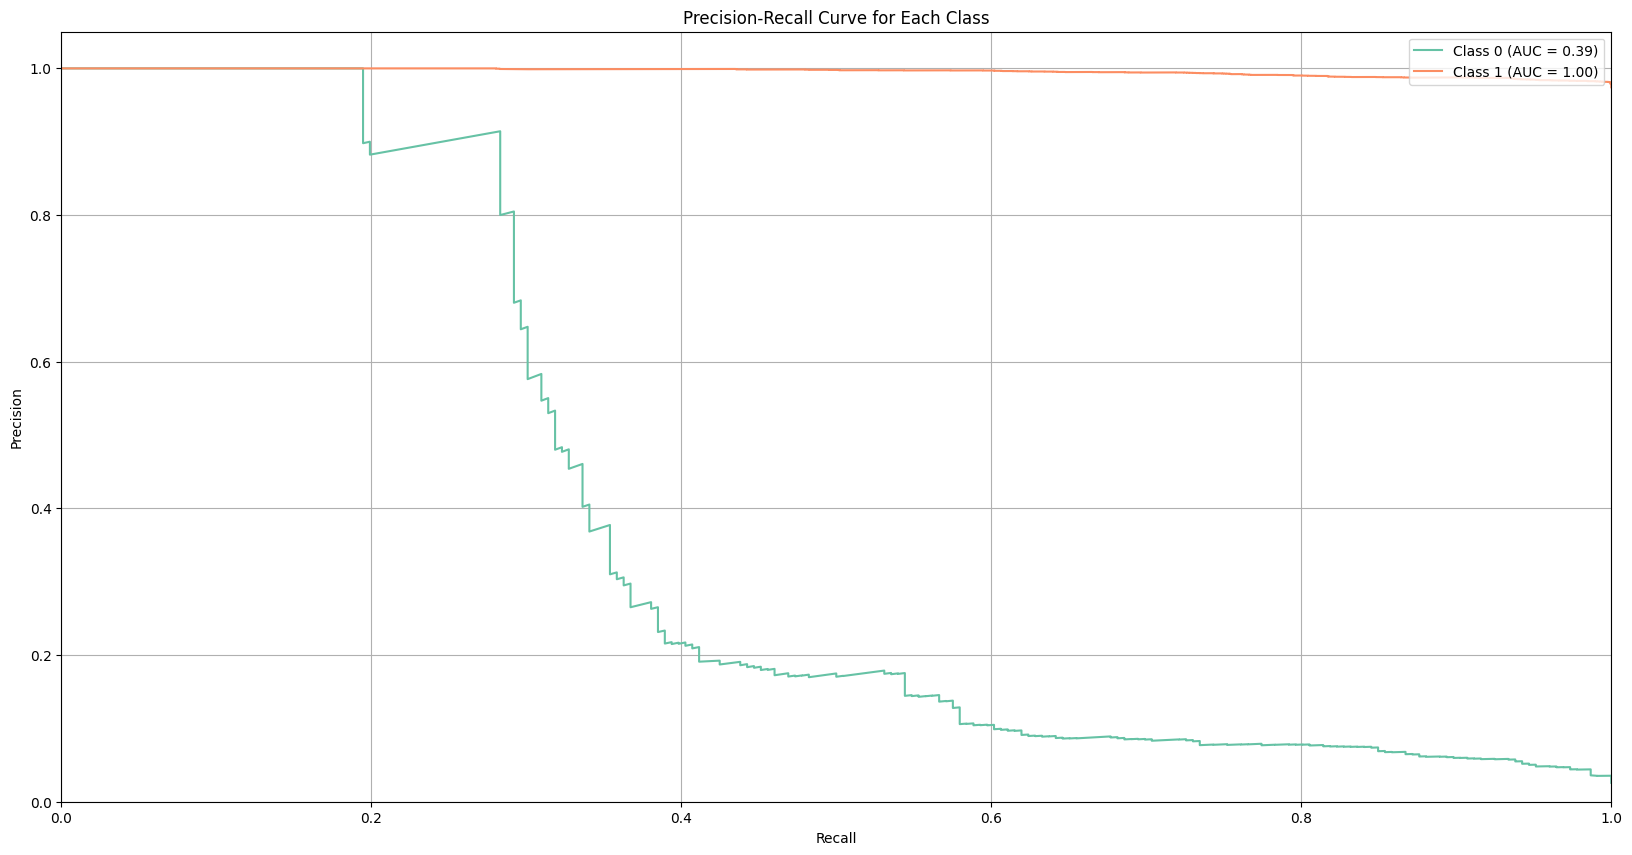

In [ ]:
print("\n--- Plotting Precision-Recall Curve ---")

class_labels = ["0", "1"]

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

y_pred_proba_test_pr = model.predict(x_test, verbose=1).flatten()

for i, label in enumerate(class_labels):
    y_test_bin = np.where(y_test == int(label), 1, 0)

    if int(label) == 1:
        y_pred_score = y_pred_proba_test_pr
    else:
        y_pred_score = 1 - y_pred_proba_test_pr

    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'Class {label} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc="upper right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True)

plt.show()

The Precision-Recall plot clearly illustrates the performance disparity:

- Class 1 (Majority): The curve remains near the top-right corner, indicating high precision is maintained even as recall increases, consistent with its high performance. The $\mathbf{AUC}$ for Class $\mathbf{1}$ is $\mathbf{0.99}$.
- Class 0 (Minority): The curve is significantly closer to the axes, indicating that achieving high recall requires sacrificing precision drastically. This confirms the difficulty in accurately identifying Class $\mathbf{0}$. The $\mathbf{AUC}$ for Class $\mathbf{0}$ is $\mathbf{0.39}$, which is low for this specific metric in a highly imbalanced scenario.

**ROC AUC Curve**


--- Plot ROC Curve for Label 0 and 1 ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

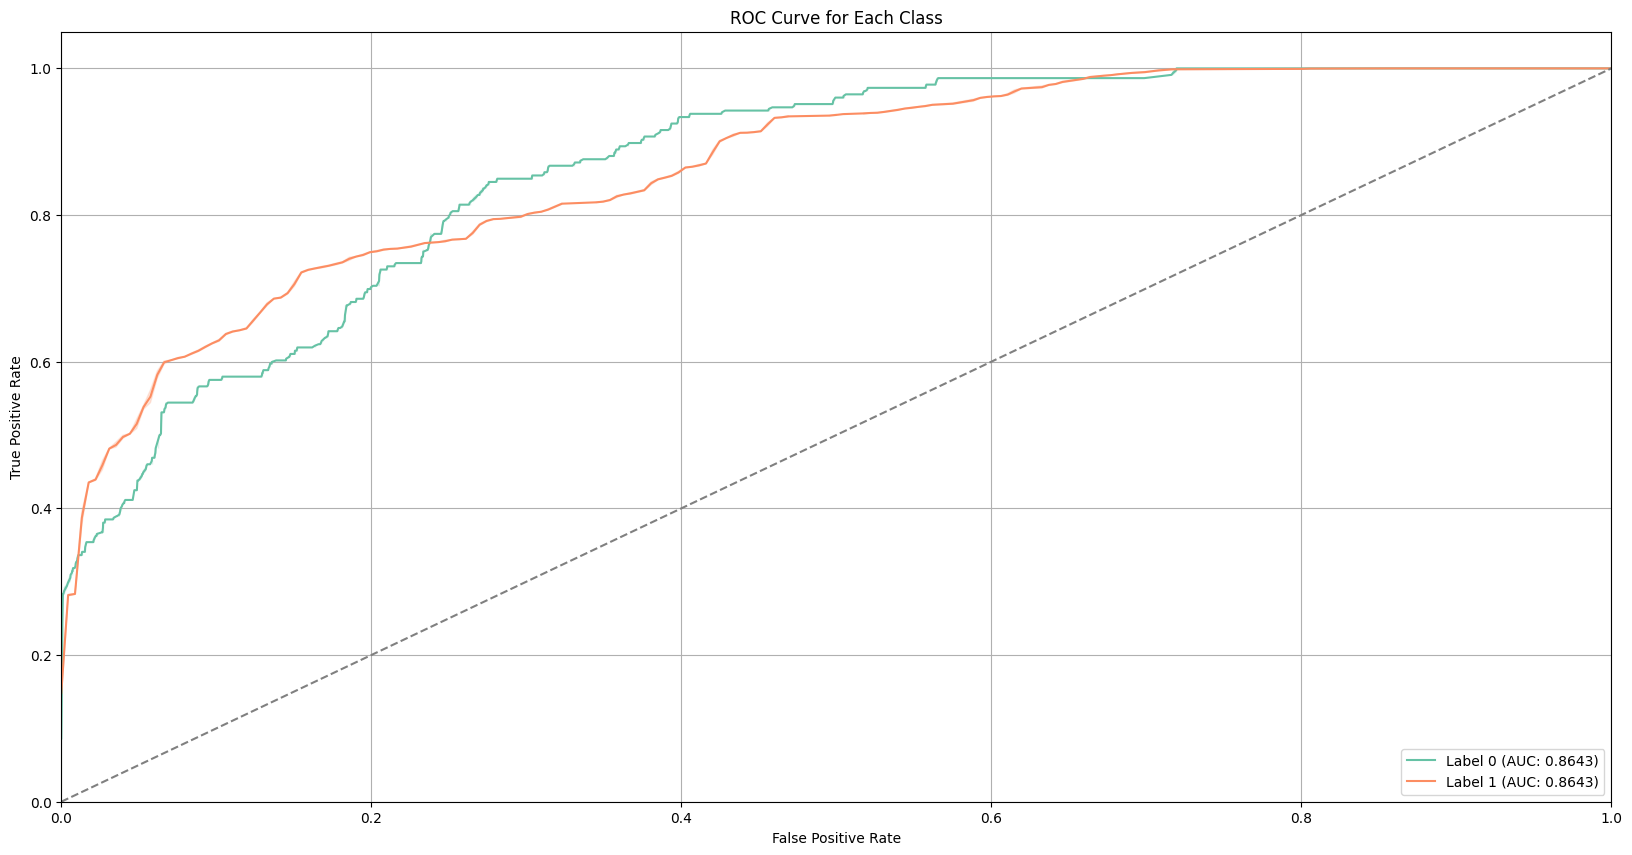


--- AUC ROC Values per Class ---
Label 0 AUC: 0.8643
Label 1 AUC: 0.8643
------------------------------


In [ ]:
print("\n--- Plot ROC Curve for Label 0 and 1 ---")

y_pred_proba_roc = model.predict(x_test, verbose=0).flatten()

class_labels_roc = ["Label 0", "Label 1"]
classes_roc = [0, 1]

fpr = dict()
tpr = dict()
roc_auc_per_class = dict()

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, class_val in enumerate(classes_roc):
    if class_val == 1:
        fpr[class_val], tpr[class_val], _ = roc_curve(y_test, y_pred_proba_roc)
    else:
        fpr[class_val], tpr[class_val], _ = roc_curve(1 - y_test, 1 - y_pred_proba_roc)

    roc_auc_per_class[class_val] = auc(fpr[class_val], tpr[class_val])

    sns.lineplot(x=fpr[class_val], y=tpr[class_val], label=f'{class_labels_roc[i]} (AUC: {roc_auc_per_class[class_val]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("\n--- AUC ROC Values per Class ---")
for class_val in classes_roc:
    print(f"{class_labels_roc[class_val]} AUC: {roc_auc_per_class[class_val]:.4f}")
print("-" * 30)

The ROC Curve shows strong performance for both classes, with an identical $\mathbf{AUC}$ of approximately $\mathbf{0.86}$. This symmetry indicates that the model is equally good at distinguishing the positive class ($\mathbf{1}$) from the negative class ($\mathbf{0}$) as it is at distinguishing the negative class ($\mathbf{0}$) from the positive class ($\mathbf{1}$), independent of the class imbalance. The curves follow the top-left quadrant closely, showing a good trade-off between the True Positive Rate and the False Positive Rate across various thresholds.

**Decision Boundary Visualization**

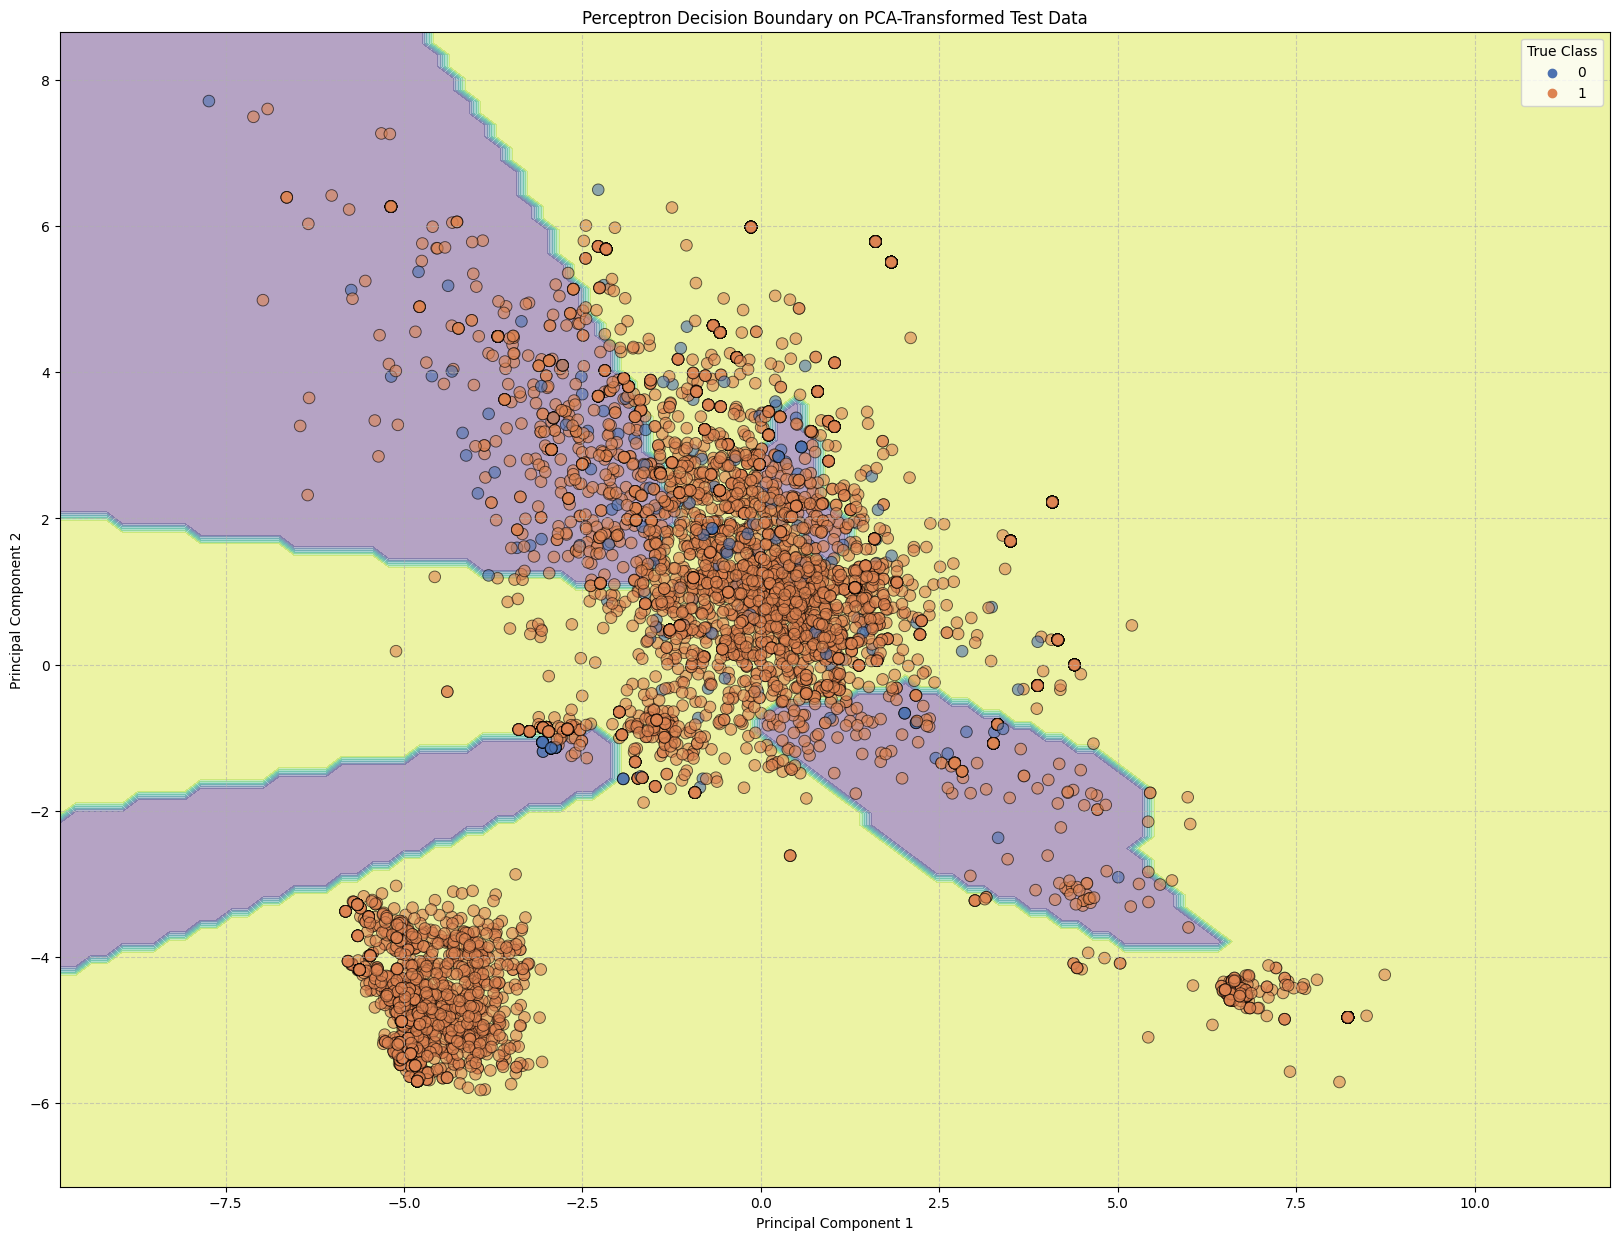

In [ ]:
plot_data_test = pd.DataFrame({
    'PC1': x_test[:, 0],
    'PC2': x_test[:, 1],
    'Target': y_test
})

plt.figure(figsize=(20, 15))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

sns.scatterplot(
    data=plot_data_test,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Test Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Decision Boundary on Test Data**

The decision boundary visualization overlays the test data onto the complex, non-linear separation regions learned during training. The plot confirms that while the boundary generally separates the large cluster of Class $\mathbf{1}$ data, many small Class $\mathbf{0}$ points are situated within the region predicted as Class $\mathbf{1}$. This visual confirms the high number of False Negatives (Class $\mathbf{0}$ points misclassified as $\mathbf{1}$) and reinforces why the Precision for the minority class is so low.

In summary, the model is excellent at classifying the majority class and shows good discrimination ability (high $\mathbf{AUC}$), but its ability to correctly identify the minority class is severely limited by the chosen decision threshold and the inherent difficulty of the imbalanced data distribution. Further work might focus on techniques like oversampling or different loss functions to improve minority class performance.

# Conclusion

This tutorial project successfully executed a complete deep learning workflow for a complex binary classification problem in malware detection using $\text{MLP}$ in TensorFlow. The key achievements include establishing a successful strategy for handling high-dimensional, sequentially-derived features, mitigating the effects of class imbalance through $\text{SMOTE}$ and $\text{PCA}$, and applying effective regularization via $\text{EarlyStopping}$. The comparison between standard and custom layer implementations showcases the framework's versatility. Ultimately, the project validates the necessity of comprehensive, macro-averaged evaluation beyond simple accuracy, proving the value of deep learning as a practical baseline for behavioral threat analysis.

# References

- [Multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron)
- [Multi-Layer Perceptron Learning in Tensorflow](https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/)
- [Multi-Layer Perceptrons: Notations and Trainable Parameters](https://www.analyticsvidhya.com/blog/2022/10/multi-layer-perceptrons-notations-and-trainable-parameters/)
- [A Deep Architecture: Multi-Layer Perceptron](https://medium.com/@nlunge786/a-deep-architecture-multi-layer-perceptron-164bc5ff3842)
- [How to Build Multi-Layer Perceptron Neural Network Models with Keras](https://machinelearningmastery.com/build-multi-layer-perceptron-neural-network-models-keras/)